# Optuna modelling workflow overview

Documented copy describing how datasets are prepared, hyperparameters tuned, and final models persisted for the MePRAM project.

## Workflow roadmap

Sequence of steps: configure targets, load datasets, tune models with Optuna, evaluate variants, and persist trained artefacts.

## Environment setup

Load Optuna, scikit-learn, plotting, and persistence utilities leveraged throughout model training.

In [3]:
import os
import joblib
import optuna
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score)
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score,
    recall_score,
    accuracy_score,
    precision_score,
    classification_report,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    precision_recall_curve,
    auc,
    roc_curve,
    brier_score_loss,
    fbeta_score
)
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
import pickle
import copy
import sys

%load_ext autoreload
%autoreload 2

## Target and feature configuration

Define modelling targets, columns to exclude, and configure seed/randomness controls.

In [4]:
TARGET_VARIABLE = "infected_yes_no" #"resultado_hemo" #all_cult_org
TARGET_REMOVE = {"infected_yes_no": "infected_yes_no", "sepsis": ["sepsis"], "resultado_hemo": ["all_cult_org", "resultado_hemo"], "all_cult_org": ["all_cult_org", "resultado_hemo"]}
OUTPUT_LOCATION = "/home/pmata/mepram_data/outputs/"
DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"

## Dataset loading and initial cleaning

Bring the merged dataset into memory, apply missing-value thresholds, and carry out baseline imputation.

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

def evaluate_models_multiclass(models, X_test, y_test, class_names):
    results = []
    classes = np.unique(y_test)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        metrics = {
            "Model": model_name,
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "ROC AUC (macro)": roc_auc_score(y_test, y_proba, labels=model.classes_, multi_class="ovr", average="macro")
        }

        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))
        results.append(metrics)
    return results

def safe_drop_columns(df, columns):
    for col in columns:
        try:
            df = df.drop(columns=col)
        except KeyError:
            print(f"Warning: Column {col} not found in DataFrame. Skipping drop.")
    return df

def load_clean_dataset(loaded_df, na_perc_limit, columns_to_delete=[], impute=True):
    print(f"Shape inicial: {loaded_df.shape}")
    missing_cols = [col for col in columns_to_delete if col not in loaded_df.columns]
    if missing_cols:
        print(f"Warning: {len(missing_cols)} columns to delete not found in table: {missing_cols}")
    clean_cols = [col for col in loaded_df.columns if col in columns_to_delete]
    loaded_df = loaded_df.drop(columns=clean_cols, errors="ignore")

    tot = loaded_df.shape[0]

    for col in loaded_df.columns:
        na_per = 1 - len(loaded_df[col].dropna()) / tot
        if na_per > na_perc_limit:
            print(f"Column {col} --> %NaN = {na_per}. deleted")
            loaded_df = loaded_df.drop(columns=col)


    if 'mujer_gestante' in loaded_df.columns:
        loaded_df['mujer_gestante'] = (
            loaded_df['mujer_gestante']
            .map({'False': 0, 'True': 1})  
            .fillna(0)  
        )

    nunique = loaded_df.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    loaded_df = loaded_df.drop(columns=constant_cols, errors="ignore")
    print(f"Dropped constant columns: {constant_cols}")

    # Drop date columns
    date_cols = [col for col in loaded_df.columns if "fecha" in col.lower()]
    loaded_df = loaded_df.drop(columns=date_cols, errors="ignore")
    print(f"Dropped date columns: {date_cols}")

    if impute is True:
        df_copy = copy.deepcopy(loaded_df.drop(columns=[TARGET_VARIABLE], errors="ignore"))
        numeric_cols = df_copy.select_dtypes(include=["int", "float"]).columns
        categorical_cols = df_copy.select_dtypes(include=["object", "category"]).columns
        binary_cols = [col for col in numeric_cols if set(df_copy[col].dropna().unique()) <= {0, 1}]

        continuous_cols = [col for col in numeric_cols if col not in binary_cols]
        categorical_numeric_cols = [
            col for col in continuous_cols if df_copy[col].nunique() <15
        ]
        continuous_cols = [col for col in continuous_cols if col not in categorical_numeric_cols]

        if binary_cols:
            binary_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[binary_cols] = binary_imputer.fit_transform(df_copy[binary_cols]).astype(int)

        if continuous_cols:
            numeric_imputer = KNNImputer(n_neighbors=5, weights="distance")
            df_copy[continuous_cols] = numeric_imputer.fit_transform(df_copy[continuous_cols])
            df_copy[continuous_cols] = df_copy[continuous_cols]

        if len(categorical_cols) > 0:
            categorical_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[categorical_cols] = categorical_imputer.fit_transform(df_copy[categorical_cols])
            df_copy[categorical_cols] = df_copy[categorical_cols].astype(str)

        if categorical_numeric_cols:
            categorical_numeric_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[categorical_numeric_cols] = categorical_numeric_imputer.fit_transform(df_copy[categorical_numeric_cols])
            df_copy[categorical_numeric_cols] = df_copy[categorical_numeric_cols].astype(int)
        df_copy[TARGET_VARIABLE] = loaded_df[TARGET_VARIABLE]
        return df_copy

    return loaded_df


def merge_columns(df_to_clean, column_list, new_col_name):
    df_to_clean[new_col_name] = df_to_clean[column_list].sum(axis=1).astype(int)
    clean_df = df_to_clean.drop(columns=column_list)
    return clean_df

df_to_clean = pd.read_csv(DATABASE_FILE)

hepatic_cols = [c for c in df_to_clean.columns if "hepatopatia" in c]
tumor_cols = [c for c in df_to_clean.columns if "cancer" in c]
for new_name, col_list in {"enf_hepaticas": hepatic_cols, "tumores": tumor_cols}.items():
    try:
        df_to_clean = merge_columns(df_to_clean, col_list, new_name)
    except Exception as e:
        print(f"Error merging columns {col_list} into {new_name}: {e}")

columns_to_delete = ["sepsis", "Unnamed: 0", "person_id", "fecha_ingreso_urgencias", "fecha_ingreso_urgencias_x", "shock_septico", "sintoma_nan", "fecha_nacimiento", "codigo_postal", "center", "dag"]
processed_df = load_clean_dataset(
    loaded_df=df_to_clean,
    na_perc_limit=0.052,
    columns_to_delete=columns_to_delete,
    impute=True
)

# Dropping low percentage focos
foco_counts = processed_df["foco"].value_counts()
most_frequent_focos = foco_counts[foco_counts > foco_counts.sum()/25].index

processed_df[processed_df["foco"].isin(most_frequent_focos)]

print("Pre-processing completed. shape without NA's: ", processed_df.dropna().shape)

Shape inicial: (3913, 155)
Column causa_inmunosupresion --> %NaN = 0.7549194991055457. deleted
Column situacion_funcional_basal --> %NaN = 0.10222335803731153. deleted
Column cirugia_previa_con_implant --> %NaN = 1.0. deleted
Column sofa --> %NaN = 0.19626884743163808. deleted
Column snc_glasgow --> %NaN = 0.12701252236135963. deleted
Column bilirrubina --> %NaN = 0.131101456682852. deleted
Column proteina_c_reactiva --> %NaN = 0.1765908510094557. deleted
Column proteina_c_reactiva_recoded --> %NaN = 0.1765908510094557. deleted
Column frec_respiratoria --> %NaN = 0.4221824686940966. deleted
Column saturacion_o2 --> %NaN = 0.05264502938921545. deleted
Column frec_respiratoria_recoded --> %NaN = 0.4221824686940966. deleted
Column saturacion_o2_recoded --> %NaN = 0.05264502938921545. deleted
Dropped constant columns: ['mujer_gestante', 'sintoma_nan_categorico']
Dropped date columns: ['ultima_fecha']
Pre-processing completed. shape without NA's:  (3913, 130)


/tmp/ipykernel_325941/2297425041.py:98: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[TARGET_VARIABLE] = loaded_df[TARGET_VARIABLE]


## Cross-validation and scoring utilities

Import sklearn components used for stratified CV, scoring, and hyperparameter evaluation with optuna

In [76]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, log_loss
import numpy as np

def fast_model_train(model, X, y, threshold=0.5, multiclass=False):
    scores = ([], [], [], [], [], [])
    X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=99)
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_val)
    y_pred = np.argmax(y_proba, axis=1)
    auc_roc = roc_auc_score(y_val, y_proba, multi_class="ovr", average="macro")
    recall = recall_score(y_val, y_pred, average="macro")
    f1 = f1_score(y_val, y_pred, average="macro")
    f2_score = fbeta_score(y_val, y_pred, beta=2, average="macro")
    #brier = brier_score_loss(y_val, y_proba )
    logloss = log_loss(y_val, y_proba)
    scores[0].append(f1)
    scores[1].append(logloss)
    scores[2].append(recall)
    scores[3].append(auc_roc)
    scores[4].append(f2_score)
    #scores[5].append(brier)
    return np.mean(scores[0]), np.mean(scores[1]), np.mean(scores[2]), np.mean(scores[3]), np.mean(scores[4])

def cv_model_train(model, X, y, threshold=0.5, multiclass=False):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = ([], [], [], [], [], [])
    for train_idx, val_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        if multiclass:
            model.fit(X_tr, y_tr)
            y_proba = model.predict_proba(X_val)
            y_pred = []
            for row in y_proba:
                if row.max() < threshold:
                    y_pred.append(-1) # Uncertain class
                else:
                    y_pred.append(np.argmax(row))
            y_pred = np.array(y_pred)
            f1 = f1_score(y_val, y_pred, average="macro")
            recall = recall_score(y_val, y_pred, average="macro")
            auc_roc = roc_auc_score(y_val, y_proba, multi_class="ovr", average="macro")
            f2 = fbeta_score(y_val, y_pred, beta=2, average="macro")
            logloss = log_loss(y_val, y_proba)
        else:
            model.fit(X_tr, y_tr)
            y_proba = model.predict_proba(X_val)[:, 1]
            y_pred = (y_proba >= threshold).astype(int)

            f1 = f1_score(y_val, y_pred)
            recall = recall_score(y_val, y_pred)
            auc_roc = roc_auc_score(y_val, y_proba)
            f2 = fbeta_score(y_val, y_pred, beta=2)
            logloss = log_loss(y_val, y_proba)
        scores[0].append(f1)
        scores[1].append(logloss)
        scores[2].append(recall)
        scores[3].append(auc_roc)
        scores[4].append(f2)

    return np.mean(scores[0]), np.mean(scores[1]), np.mean(scores[2]), np.mean(scores[3]), np.mean(scores[4])

def objective_random_forest(trial, X, y, multiclass=False):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000),   # number of trees
        "max_depth": trial.suggest_int("max_depth", 3, 30),             # limit tree depth
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),  # min samples to split
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),    # min samples per leaf
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "class_weight": "balanced_subsample",   # very useful in imbalanced multiclass
        "random_state": 42,
        "n_jobs": -1
    }
    if multiclass:
        threshold = trial.suggest_float('threshold', 0.5)
    else:
        threshold = trial.suggest_float('threshold', 0.2, 0.8)
    model = RandomForestClassifier(**params)
    f1_score, logloss, recall, auc_roc, f2_score = fast_model_train(model, X, y, threshold=threshold, multiclass=multiclass)
    return f1_score, logloss

def objective_xgboost(trial, X, y, multiclass=False):
    pos, neg = np.sum(y==1), np.sum(y==0)
    scale_pos_weight = neg / pos
    params = {
        'verbosity': 0,
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        #'early_stopping_rounds': 50,
        "use_label_encoder": False,
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5.0),
        #"class_weight": "balanced", 
        #'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        #'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        #'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'scale_pos_weight': scale_pos_weight,
        #'max_features': trial.suggest_float('max_features', 0.5, 1.0)
    }
    if multiclass:
        threshold = 0.5
    else:
        threshold = trial.suggest_float('threshold', 0.2, 0.8)
    model = XGBClassifier(**params)
    f1_score, logloss, recall, auc_roc, f2_score = fast_model_train(model, X, y, threshold=threshold)
    return f1_score, logloss

def objective_svm(trial, X, y, multiclass=False):
    params = {
        "C": trial.suggest_float("C", 0.01, 10.0, log=True),
        "kernel": trial.suggest_categorical("kernel", ["linear", "rbf"]),
        "gamma": "scale",
        "class_weight": "balanced",
        "probability": True,
        "random_state": 42
    }
    if multiclass:
        threshold = 0.5
    else:
        threshold = trial.suggest_float('threshold', 0.2, 0.8)
    model = SVC(**params)
    f1_score, logloss, recall, auc_roc, f2_score, brier = cv_model_train(model, X, y, threshold=threshold, multiclass=multiclass)
    return f1_score, logloss

def evaluate_models(models, X_test, y_test):
    results = []
    for model_name, model in models.items():
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        if model_name.split(': ')[-1] and ': ' in model_name and y_pred_prob is not None:
            threshold = float(model_name.split(': ')[-1])
            y_pred = (model.predict_proba(X_test)[:, 1] >= threshold).astype(int).ravel()
        else:
            y_pred = model.predict(X_test)
        metrics = {
            'Model': model_name,
            'F1': f1_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred),
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred),
            'ROC AUC': roc_auc_score(y_test, y_pred_prob) if y_pred_prob is not None else 'N/A'
        }
        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred))
        results.append(metrics)
    return pd.DataFrame(results)

def plot_optuna_metrics(studies):
    # Plot F1 Score
    plt.figure(figsize=(12, 8))
    for model_name, study in studies.items():
        trials_f1 = [trial.values[0] for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
        plt.plot(range(1, len(trials_f1) + 1), trials_f1, label=f"{model_name} - F1")

    plt.title("F2-Score Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.grid(True)
    plt.show()

    """# Plot LogLoss
    plt.figure(figsize=(12, 8))
    for model_name, study in studies.items():
        trials_logloss = [trial.values[1] for trial in study.trials if trial.state == optuna.trial.TrialState.COMPLETE]
        plt.plot(range(1, len(trials_logloss) + 1), trials_logloss, label=f"{model_name} - LogLoss")

    plt.title("LogLoss Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel("LogLoss")
    plt.legend()
    plt.grid(True)
    plt.show()"""
    
def plot_metrics(models, X_test, y_test):
    plt.figure(figsize=(15, 5))

    # ROC Curve
    plt.subplot(1, 3, 1)
    for model_name, model in models.items():
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        if y_pred_prob is not None:
            fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f"{model_name.split(":")[0]} (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # Recall-Precision Curve
    plt.subplot(1, 3, 2)
    for model_name, model in models.items():
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        if y_pred_prob is not None:
            precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
            plt.plot(recall, precision, label=f"{model_name.split(":")[0]}")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.subplot(1, 3, 3)
    for model_name, model in models.items():
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        if y_pred_prob is not None:
            prob_true, prob_pred = calibration_curve(y_test, y_pred_prob, n_bins=10)
            plt.plot(prob_pred, prob_true, marker='o', label=f'{model_name.split(":")[0]}')
            plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Fraction of Positives')
    plt.title('Calibration Curve')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    for model_name, model in models.items():
        y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
        threshold = model_name.split(': ')[-1] if ': ' in model_name else None
        if threshold and y_pred_prob is not None:
            y_pred = (model.predict_proba(X_test)[:, 1] >= float(threshold)).astype(int).ravel()
        else:
            y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(5, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Sepsis", "Sepsis"], yticklabels=["No Sepsis", "Sepsis"])
        plt.title(f"Confusion Matrix for {model_name.split(":")[0]}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
import os
import pickle
import copy

def predict_with_threshold(model, X, classes, threshold=None):
    """
    Predict multiclass labels with a confidence threshold.
    If max probability < threshold → assign 'Unknown'
    """
    # Predict probabilities
    y_proba = model.predict_proba(X)

    # Get argmax and max probability
    y_pred_idx = np.argmax(y_proba, axis=1)
    y_max_prob = np.max(y_proba, axis=1)

    # Choose default threshold if not provided
    if threshold is None:
        n_classes = y_proba.shape[1]
        threshold = 1 / n_classes + 0.2  # adaptive heuristic

    # Create predicted labels
    y_pred = np.array([classes[i] if p >= threshold else "Unknown"
                       for i, p in zip(y_pred_idx, y_max_prob)])

    return y_pred, y_max_prob

def evaluate_models_multiclass(models, X_test, y_test, class_names):
    results = []
    classes = np.unique(y_test)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        metrics = {
            "Model": model_name,
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "ROC AUC (macro)": roc_auc_score(y_test, y_proba, labels=model.classes_, multi_class="ovr", average="macro")
        }

        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))
        results.append(metrics)

    return pd.DataFrame(results)

def plot_optuna_metrics_multiclass(studies, metric_names=("F1 (macro)", "LogLoss")):
    """
    Plot the evolution of macro F1 and LogLoss across trials for each model.
    
    studies : dict
        {"ModelName": optuna.study.Study, ...}
    metric_names : tuple
        Names of the two metrics being optimized (default: F1-macro, LogLoss).
    """
    # --- Plot F1 ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_f1 = [
            trial.values[0] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_f1) + 1), trials_f1, label=f"{model_name}")
    plt.title(f"{metric_names[0]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[0])
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot LogLoss ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_ll = [
            trial.values[1] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_ll) + 1), trials_ll, label=f"{model_name}")
    plt.title(f"{metric_names[1]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[1])
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_metrics_multiclass(models, X_test, y_test, classes, class_names):
    # ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f"{model_name} - class {class_names[i]}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curves (per class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # PR curves
    plt.subplot(1, 2, 2)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            precision, recall, _ = precision_recall_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(recall, precision, label=f"{model_name} - class {class_names[i]}")
    plt.title("Precision-Recall Curves (per class)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Confusion matrices
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix for {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

## Train sepsis model with Optuna

Set up data pipelines, objective function, and evaluation metrics for the sepsis detection task.

### Optuna optimisation for binary problem (sepsis)

Execute the study: define objective, run trials, and compare baseline models.

[I 2025-09-30 10:38:38,789] A new study created in memory with name: no-name-5df20941-d71f-49e2-939e-e06356863e2f


Could not delete column prev_ultima_fecha: "['prev_ultima_fecha'] not found in axis"


/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/optuna/trial/_trial.py:682: RuntimeWarning: Inconsistent parameter values for distribution with name "max_depth"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, 'low': 3, 'high': 30}
  warnings.warn(
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/optuna/trial/_trial.py:682: RuntimeWarning: Inconsistent parameter values for distribution with name "min_samples_split"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 1, '


Classification Report for Random Forest: 0.491892710505854:

              precision    recall  f1-score   support

         0.0       0.85      0.84      0.85       540
         1.0       0.82      0.84      0.83       486

    accuracy                           0.84      1026
   macro avg       0.84      0.84      0.84      1026
weighted avg       0.84      0.84      0.84      1026

Model Comparison:
                               Model        F1    Recall  Accuracy  Precision  \
0  Random Forest: 0.491892710505854  0.832994  0.841564  0.840156   0.824597   

    ROC AUC  
0  0.913098  
Scaler saved to /home/pmata/mepram_data/output_testing/scaler.pkl
Model 'Random Forest: 0.491892710505854' saved to /home/pmata/mepram_data/output_testing/random_forest:_0.491892710505854_model.pkl


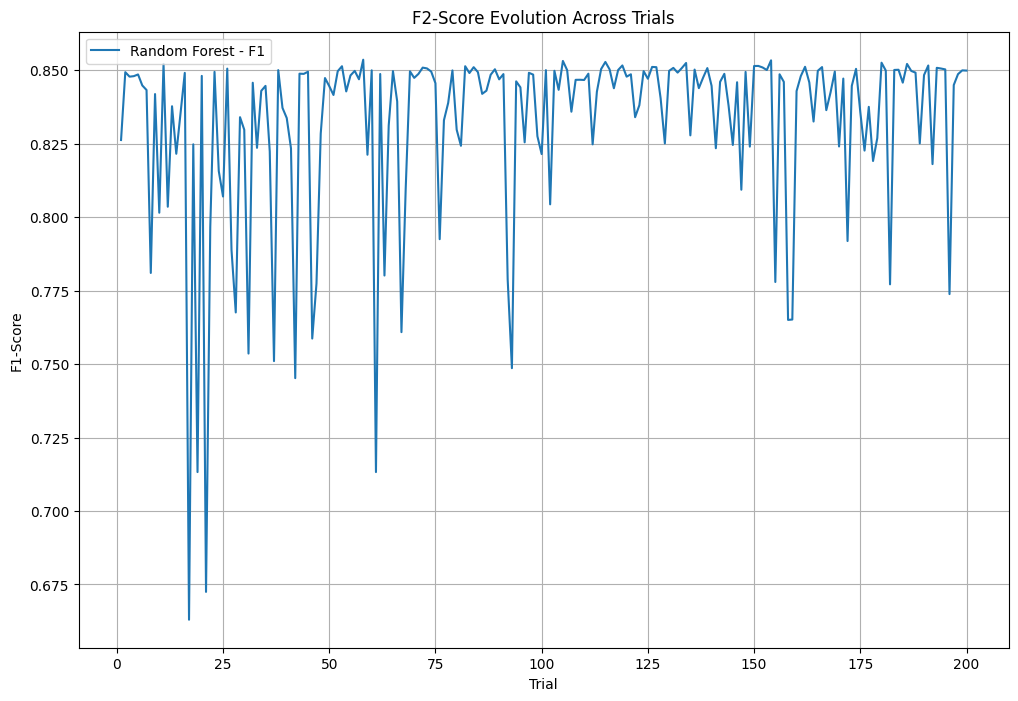

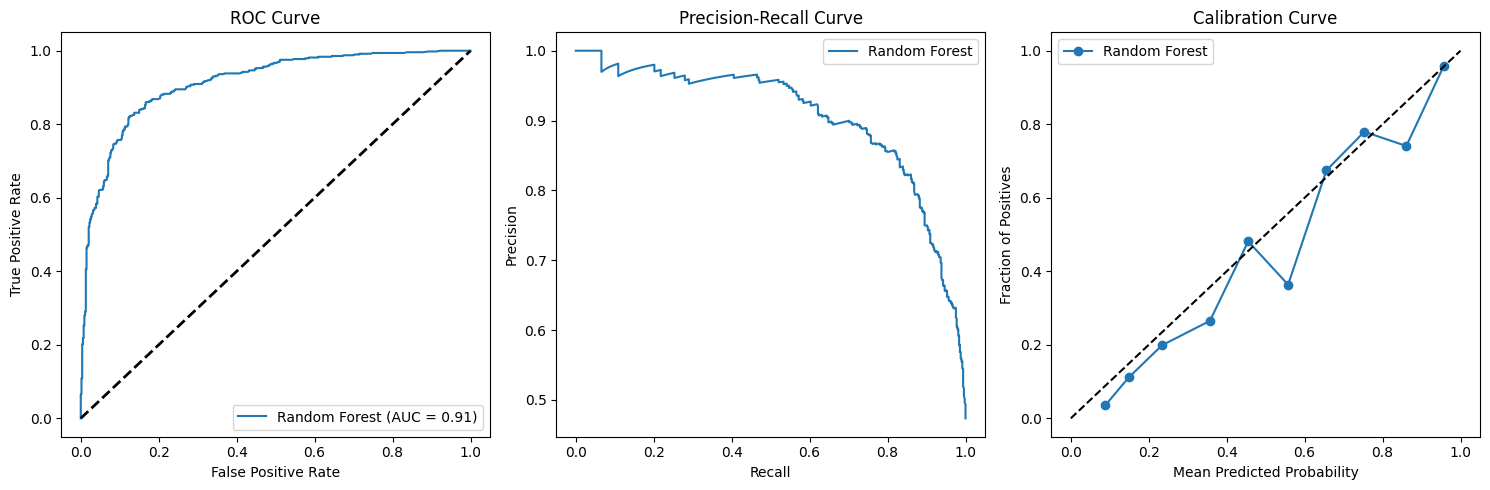

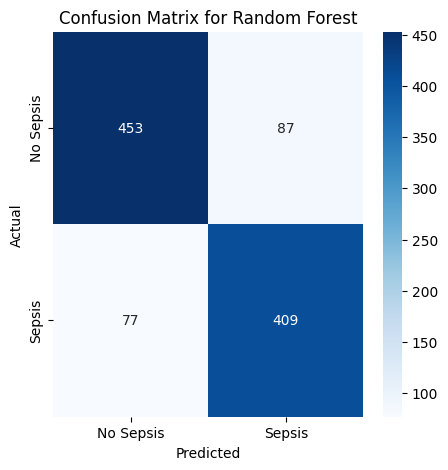

In [ ]:
import os
import pickle
import copy

if __name__ == "__main__":
    output_location = "/home/pmata/mepram_data/output_testing/"
    output_filename = "model_comparison_infecsino_vf.csv"
    cols_to_delete = ["person_id", "fecha_ingreso_urgencias", "shock_septico", "prev_ultima_fecha", "ultima_fecha", "foco",
        "fecha_nacimiento", "codigo_postal","fecha_ingreso_urgencias_x", "center", "dag", "mujer_gestante"]
    for col in cols_to_delete:
        try:
            processed_df = processed_df.drop(col, axis=1)
        except Exception as e:
            print(f"Could not delete column {col}: {str(e)}")

    test_df = copy.deepcopy(processed_df)
    target_variable = TARGET_VARIABLE #infectes_yes_no
    encode = False
    if encode:
        le = LabelEncoder()
        test_df[target_variable] = le.fit_transform(test_df[target_variable])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"Encoded variables: {mapping}")
    reduction_list = ['edad', 'hipotension', 'taquipnea', 'respiracion', 'cardiovascular', 'estado_mental_alterado', 'creatinina', "tension_arterial_recoded", "enf_hepaticas"]
    selected = reduction_list
    if target_variable in selected:
        X = test_df[selected].drop(target_variable, axis=1)
    else:
        X = test_df[selected]
    y = test_df[target_variable]

    scaler = MinMaxScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

    rf_study = optuna.create_study(directions=["maximize", "minimize"])
    rf_study.optimize(lambda trial: objective_random_forest(trial, X, y), n_trials=200, multiclass=False)
    best_rf_params = rf_study.best_trials[0].params
    rf_thresh = best_rf_params.pop("threshold")
    best_rf_model = RandomForestClassifier(**best_rf_params).fit(X_train, y_train)
    best_rf_metrics = cv_model_train(best_rf_model, X, y)

    xgb_study = optuna.create_study(directions=["maximize", "minimize"])
    xgb_study.optimize(lambda trial: objective_xgboost(trial, X, y), n_trials=200, multiclass=False)
    best_xgb_params = xgb_study.best_trials[0].params
    xgb_thresh = 0.5#best_xgb_params.pop("threshold")
    best_xgb_model = XGBClassifier(**best_xgb_params).fit(X_train, y_train)
    best_xgb_metrics = cv_model_train(best_xgb_model, X, y)

    svm_study = optuna.create_study(directions=["maximize", "minimize"])
    svm_study.optimize(lambda trial: objective_svm(trial, X, y), n_trials=200, multiclass=False)
    best_svm_params = svm_study.best_trials[0].params
    svm_thresh = 0.5#best_svm_params.pop("threshold")
    best_svm_model = SVC(**best_svm_params, probability=True).fit(X_train, y_train)
    best_svm_metrics = cv_model_train(best_svm_model, X, y)

    models = {
        f"Random Forest: {rf_thresh}": best_rf_model,
        f"XGBoost: {xgb_thresh}": best_xgb_model,
        f"SVM: {svm_thresh}": best_svm_model
    }
    results = evaluate_models(models, X_test, y_test)
    
    today = pd.Timestamp.now().strftime("%Y-%m-%d_%H:%M:%S_")
    
    print("Model Comparison:\n", results)
    results.to_csv(os.path.join(output_location, today + output_filename), index=False)
    
    scaler_path = os.path.join(output_location, today + "scaler.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {scaler_path}")

    for model_name, model in models.items():
        model_path = os.path.join(output_location, today + f"{model_name.replace(' ', '_').lower()}_model.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model '{model_name}' saved to {model_path}")
    
    plot_optuna_metrics(
        studies={
            "Random Forest": rf_study,
            "XGBoost": xgb_study,
            "SVM": svm_study
        },
    )

    plot_metrics(models, X_test, y_test)

## Compare imputation strategies

Test different numerical and categorical imputation schemes to understand their effect on model performance.

### Evaluate imputed dataset variants

Compare validation metrics across KNN, mean/mode, and other imputers to pick the most reliable strategy.

In [ ]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

def load_clean_dataset_impute(loaded_df, na_perc_limit, columns_to_delete=[]):
    print(f"Shape inicial: {loaded_df.shape}")

    loaded_df = loaded_df.drop(columns=columns_to_delete, errors="ignore")

    tot = loaded_df.shape[0]

    for col in loaded_df.columns:
        na_per = 1 - len(loaded_df[col].dropna()) / tot
        if na_per > na_perc_limit:
            print(f"Column {col} --> %NaN = {na_per}. deleted")
            loaded_df = loaded_df.drop(columns=col)


    if 'mujer_gestante' in loaded_df.columns:
        loaded_df['mujer_gestante'] = (
            loaded_df['mujer_gestante']
            .map({'False': 0, 'True': 1})  
            .fillna(0)  
        )

    numeric_cols = loaded_df.select_dtypes(include=["int", "float"]).columns
    categorical_cols = loaded_df.select_dtypes(include=["object", "category"]).columns
    binary_cols = [col for col in numeric_cols if set(loaded_df[col].dropna().unique()) <= {0, 1}]
    continuous_cols = [col for col in numeric_cols if col not in binary_cols]
    categorical_numeric_cols = [
        col for col in continuous_cols if loaded_df[col].nunique() <15
    ]
    continuous_cols = [col for col in continuous_cols if col not in categorical_numeric_cols]
    
    if binary_cols:
        binary_imputer = SimpleImputer(strategy="most_frequent")
        loaded_df[binary_cols] = binary_imputer.fit_transform(loaded_df[binary_cols]).astype(int)

    if continuous_cols:
        numeric_imputer = KNNImputer(n_neighbors=5, weights="distance")
        loaded_df[continuous_cols] = numeric_imputer.fit_transform(loaded_df[continuous_cols])
        loaded_df[continuous_cols] = loaded_df[continuous_cols].round(1)

    if len(categorical_cols) > 0:
        categorical_imputer = SimpleImputer(strategy="most_frequent")
        loaded_df[categorical_cols] = categorical_imputer.fit_transform(loaded_df[categorical_cols])
        loaded_df[categorical_cols] = loaded_df[categorical_cols].astype(int)
    
    if categorical_numeric_cols:
        categorical_numeric_imputer = SimpleImputer(strategy="most_frequent")
        loaded_df[categorical_numeric_cols] = categorical_numeric_imputer.fit_transform(loaded_df[categorical_numeric_cols])
        loaded_df[categorical_numeric_cols] = loaded_df[categorical_numeric_cols].astype(int)

    print(f"Shape final: {loaded_df.shape}")
    return loaded_df


def combine_columns(df_to_clean, column_list, new_col_name):
    df_to_clean[new_col_name] = df_to_clean[column_list].sum(axis=1).astype(int)
    clean_df = df_to_clean.drop(columns=column_list)
    return clean_df


DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"
df_to_clean = pd.read_csv(DATABASE_FILE)

hepatic_cols = [c for c in df_to_clean.columns if "hepatopatia" in c]
tumor_cols = [c for c in df_to_clean.columns if "cancer" in c]
for new_name, col_list in {"enf_hepaticas": hepatic_cols, "tumores": tumor_cols}.items():
    df_to_clean = combine_columns(df_to_clean, col_list, new_name)

columns_to_delete = ["Unnamed: 0", "person_id", "fecha_ingreso_urgencias", "shock_septico", "foco", "sintoma_nan", "fecha_nacimiento", "codigo_postal", "center", "dag"]
processed_df = load_clean_dataset_impute(
    loaded_df=df_to_clean,
    na_perc_limit=0.1,
    columns_to_delete=columns_to_delete
)

In [ ]:
import optuna.visualization as vis
#vis.plot_optimization_history(xgb_study).show()
#vis.plot_optimization_history(rf_study).show()
#vis.plot_optimization_history(svm_study).show()

vis.plot_param_importances(xgb_study).show()
vis.plot_param_importances(rf_study).show()
vis.plot_param_importances(svm_study).show()

## Feature subset selection

Load the feature shortlist from `reduction_var` and restrict the modelling frame accordingly.

### Restrict frame to curated features

Subset the dataframe using the features exported from the reduction notebook before fitting models.

In [ ]:
selected_for_sepsis = ['edad', 'indice_de_charlson', 'respiracion', 'cardiovascular', 'plaquetas', 'creatinina', 'estado_mental_alterado', 'temperatura', 'frec_cardiaca', 'taquipnea', 'tension_arterial', 'hipotension', 'saturacion_o2', 'tension_arterial_recoded']

In [12]:
selected_for_etiology = ['edad',
  'indice_de_charlson',
  'foco',
  'respiracion',
  'plaquetas',
  'creatinina',
  'temperatura',
  'frec_cardiaca',
  'tension_arterial',
  'temperatura_recoded',
  'frec_cardiaca_recoded',
  'tension_arterial_recoded',
  'sintoma_tos_categorico',
  'antib_previo_total_dias',
  'ultimo_antib']

In [ ]:
from itertools import combinations
def create_combinations(processed_df, list_features, drop=False):
    for feature1, feature2 in combinations(list_features, 2):
        processed_df[f"{feature1}_{feature2}"] = processed_df[feature1] + processed_df[feature2]
    if drop:
        processed_df.drop(list_features, axis=1)
    return processed_df

## Prepare data for training

Encode categoricals, scale numerics, and partition data prior to fitting tuned models.

### Train/test split and scaling details

Apply stratified splits, standardise inputs where necessary, and prepare targets for modelling.

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score, precision_recall_curve, average_precision_score
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import pandas as pd
import numpy as npa
import copy
from itertools import combinations
from collections import defaultdict
import copy

from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB

list_of_features = selected_for_etiology

invalid_cols = ["sepsis", "qsofa", "vasopresores", "hipotension", "freq_bacteria", "freq_bac_foco", *TARGET_REMOVE[TARGET_VARIABLE]]
invalid_orgs = ["Enterococcus", "_Fungi", "_Other bacteria"]#, "_Enterobacteria"]
invalid_focos = ["catéter venoso", "vías altas respiratorias", "cardiovascular", "osteoarticular", "sistema nervioso central", "genital"]
cols_to_encode = ["ultimo_antib", TARGET_VARIABLE]
test_df = copy.deepcopy(processed_df)

print("Initial dataset shape: ", test_df.shape)

test_df = test_df[~test_df[TARGET_VARIABLE].isin(invalid_orgs)]
test_df = test_df[~test_df["foco"].isin(invalid_focos)]
test_df = test_df.dropna(subset=list_of_features)

print("Final dataset shape: ", test_df.shape)

for col in cols_to_encode:
    le = LabelEncoder()
    test_df[col] = le.fit_transform(test_df[col].astype(str))
    if col == TARGET_VARIABLE:
        mapping = dict(zip(le.classes_, range(len(le.classes_))))

X = safe_drop_columns(test_df, invalid_cols)

X = X[list_of_features]

le = LabelEncoder()
y = test_df[TARGET_VARIABLE]
classes = np.unique(y)
print("Class mapping:", mapping)

y = pd.Series(y, name=TARGET_VARIABLE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=99
)
tbl = (
    X_train.assign(bacteria=y_train)  # y_train are class labels aligned to X_train
          .pivot_table(index="foco", columns="bacteria", values=None, aggfunc="size", fill_value=0)
)

k = 1.0
col_sums = tbl.sum(axis=0)
pf_b = (tbl + k).div(col_sums + k * tbl.shape[0], axis=1)
support_b = col_sums
classes = pf_b.columns.to_numpy()

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

min_class_samples = y_train.value_counts().min()
smote_k = max(1, min(5, min_class_samples - 1))
counts = y.value_counts()
max_class = counts.idxmax()
max_count = counts.max()
target_frac = 0.30
target_size = int(max_count * target_frac)

sampling_strategy = {}
for cls, count in counts.items():
    if cls == max_class:
        sampling_strategy[cls] = count
    else:
        target = min(count * 10, target_size)
        sampling_strategy[cls] = max(count, target)
sampler = SMOTE(random_state=99, k_neighbors=smote_k, sampling_strategy=sampling_strategy)

X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_scaled, y_train)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)
y_train_balanced = pd.Series(y_train_balanced, name=TARGET_VARIABLE)

cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)
scorer = make_scorer(fbeta_score, beta=2, average="macro")


Initial dataset shape:  (3693, 130)
Final dataset shape:  (3495, 130)
Class mapping: {'Escherichia coli': 0, 'Klebsiella pneumoniae': 1, 'NEGATIVE': 2, 'Pseudomonas aeruginosa': 3, 'Staphylococcus aureus': 4, 'Streptococcus pneumoniae': 5, '_Enterobacteria': 6}


## Evaluate feature subset without imputation

Investigate performance when using the selected features but skipping imputation, testing robustness.

### Benchmark without extra imputation

Run sensitivity analyses that exclude additional imputation to understand reliance on preprocessing.

In [75]:
import os
import pickle
import copy

if __name__ == "__main__":
    #DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"
    output_location = "/home/pmata/mepram_data/output_testing/"
    """processed_df = pd.read_csv(DATABASE_FILE)
    #processed_df = preprocess_data(database_file)
    list_of_features = selected_for_etiology # selected_for_sepsis
    test_df = copy.deepcopy(processed_df)"""
    """if TARGET_VARIABLE in selected:
        X = test_df[selected].drop(TARGET_REMOVE[TARGET_VARIABLE], axis=1)
    else:
        X = test_df[selected]
    y = test_df[TARGET_VARIABLE]

    scaler = MinMaxScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)"""

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)

    rf_study = optuna.create_study(directions=["maximize", "minimize"])
    rf_study.optimize(lambda trial: objective_random_forest(trial, X_train_balanced, y_train_balanced, multiclass=True), n_trials=200)
    best_rf_params = rf_study.best_trials[0].params
    rf_thresh = best_rf_params.pop("threshold")
    best_rf_model = RandomForestClassifier(**best_rf_params).fit(X_train_balanced, y_train_balanced)
    #best_rf_metrics = cv_model_train(best_rf_model, X, y)

    """xgb_study = optuna.create_study(directions=["maximize", "minimize"])
    xgb_study.optimize(lambda trial: objective_xgboost(trial, X, y), n_trials=100)
    best_xgb_params = xgb_study.best_trials[0].params
    xgb_thresh = best_xgb_params.pop("threshold")
    best_xgb_model = XGBClassifier(**best_xgb_params).fit(X_train, y_train)
    #best_xgb_metrics = cv_model_train(best_xgb_model, X, y)

    svm_study = optuna.create_study(directions=["maximize", "minimize"])
    svm_study.optimize(lambda trial: objective_svm(trial, X, y), n_trials=100)
    best_svm_params = svm_study.best_trials[0].params
    svm_thresh = best_svm_params.pop("threshold")
    best_svm_model = SVC(**best_svm_params, probability=True).fit(X_train, y_train)
    #best_svm_metrics = cv_model_train(best_svm_model, X, y)"""

    models = {
        f"Random Forest: {rf_thresh}": best_rf_model,
        #f"XGBoost: {xgb_thresh}": best_xgb_model,
        #f"SVM: {svm_thresh}": best_svm_model
    }
    results = evaluate_models_multiclass(models, X_test, y_test, class_names=classes)

    print("Model Comparison:\n", results)
    results.to_csv(os.path.join(output_location, "model_comparison_sepsis.csv"), index=False)
    
    scaler_path = os.path.join(output_location, "scaler.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {scaler_path}")

    for model_name, model in models.items():
        model_path = os.path.join(output_location, f"{model_name.replace(' ', '_').lower()}_model.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model '{model_name}' saved to {model_path}")
    studies={
            "Random Forest": rf_study,
            #"XGBoost": xgb_study,
            #"SVM": svm_study
    },

    # Plot metrics
    plot_optuna_metrics(studies)
    
    plot_metrics(models, X_test, y_test)

[I 2025-10-30 11:10:16,263] A new study created in memory with name: no-name-d57cd4a6-7fe1-412e-8f85-5f853995a8b0


[I 2025-10-30 11:10:16,873] Trial 0 finished with values: [0.7059599621104455, 1.0515113835000935] and parameters: {'n_estimators': 334, 'max_depth': 29, 'min_samples_split': 17, 'min_samples_leaf': 6, 'bootstrap': True}.
[I 2025-10-30 11:10:17,407] Trial 1 finished with values: [0.7878343120076992, 0.8483655749651913] and parameters: {'n_estimators': 486, 'max_depth': 12, 'min_samples_split': 3, 'min_samples_leaf': 3, 'bootstrap': False}.
[I 2025-10-30 11:10:18,840] Trial 2 finished with values: [0.3587784490265152, 1.641157704232438] and parameters: {'n_estimators': 368, 'max_depth': 3, 'min_samples_split': 7, 'min_samples_leaf': 1, 'bootstrap': True}.
[I 2025-10-30 11:10:19,686] Trial 3 finished with values: [0.6939025828725249, 1.0732966707158182] and parameters: {'n_estimators': 359, 'max_depth': 22, 'min_samples_split': 4, 'min_samples_leaf': 8, 'bootstrap': True}.
[I 2025-10-30 11:10:20,231] Trial 4 finished with values: [0.8414441901989732, 0.715126191944566] and parameters: {'

KeyError: 'threshold'

In [ ]:
    models = {
        f"Random Forest: {rf_thresh}": best_rf_model,
        #f"XGBoost: {xgb_thresh}": best_xgb_model,
        #f"SVM: {svm_thresh}": best_svm_model
    }

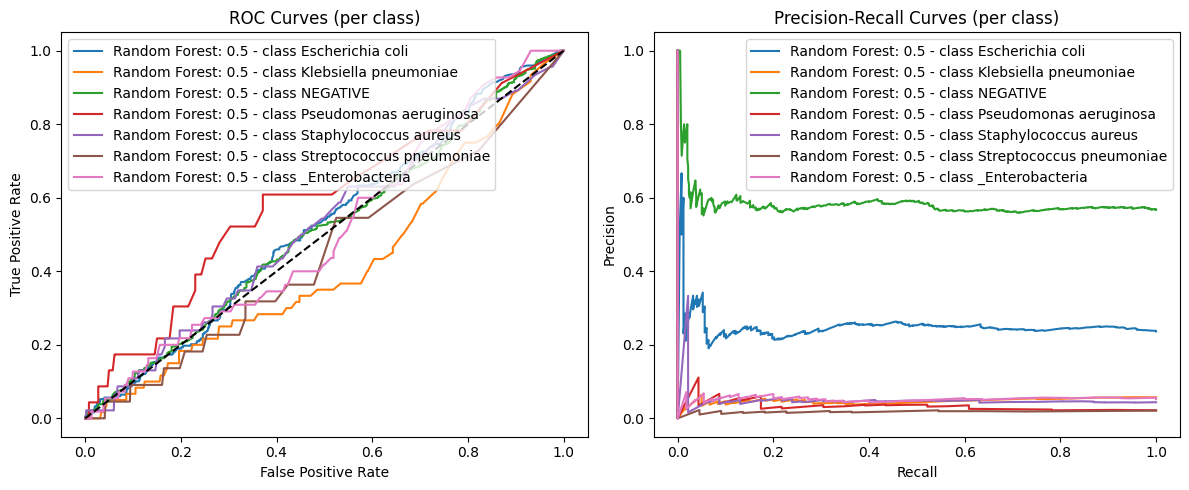

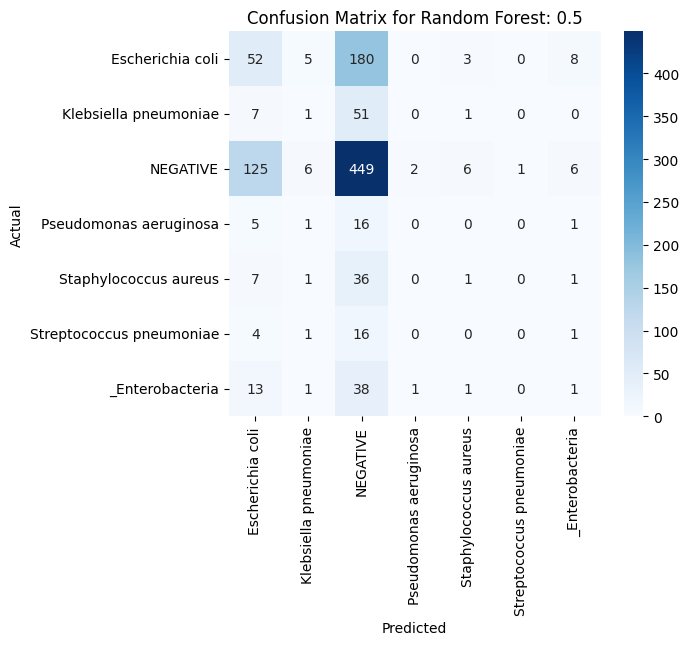

In [88]:
plot_metrics_multiclass(models, X_test_scaled, y_test, classes=np.unique(y), class_names=list(mapping.keys()))

In [ ]:
results = evaluate_models_multiclass(models, X_test, y_test)


TypeError: evaluate_models_multiclass() missing 1 required positional argument: 'class_names'

In [65]:
best_rf_model

RandomForestClassifier(bootstrap=False, max_depth=26, min_samples_leaf=2,
                       min_samples_split=7, n_estimators=522)

In [64]:
results = evaluate_models_multiclass(models, X_test, y_test, class_names=classes)



Classification Report for Random Forest: 0.2805045667301713:

              precision    recall  f1-score   support

           0       0.31      0.22      0.26       248
           1       0.22      0.03      0.06        60
           2       0.59      0.79      0.68       595
           3       0.10      0.13      0.11        23
           4       0.07      0.07      0.07        46
           5       0.00      0.00      0.00        22
           6       0.00      0.00      0.00        55

    accuracy                           0.51      1049
   macro avg       0.19      0.18      0.17      1049
weighted avg       0.43      0.51      0.46      1049



/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

In [ ]:
DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"
output_location = "/home/pmata/mepram_data/output_testing/"
processed_df = pd.read_csv(DATABASE_FILE)
focoss = {
    1: "pulmonar",
    2: "intraabdominal",
    3: "biliar",
    4: "urinario",
    5: "cardiovascular",
    6: "piel",
    7: "sistema nervioso central",
    8: "cateter venoso",
    9: "vías altas respiratorias",
    10: "osteoarticular",
    11: "genital",
    12: "desconocido",
}
processed_df["foco"] = processed_df["foco"].map(focoss)
processed_df = processed_df[~processed_df["foco"].isin(["piel", "osteoarticular", "biliar", "genital", "sistema nervioso central", "cateter venoso", "vías altas respiratorias", "cardiovascular"])]
#processed_df["foco"] = processed_df["foco"].map(lambda x: {"biliar": "otros", "genital": "otros", "sistema nervioso central": "otros", "cateter venoso": "otros", "vías altas respiratorias": "otros", "cardiovascular": "otros"}.get(x, x))

In [ ]:
hemo_df = pd.read_csv("/home/pmata/mepram_data/df_hemo_merged.csv")
import copy


In [107]:
test_df = test_df[~test_df["resultado_hemo"].isin(["_Fungi", "Enterococcus"])].reset_index(drop=True)

## Train foco/etiology model

Adapt the Optuna objective to predict infection focus / etiology, including target-specific preprocessing.

### Configure Optuna for foco/etiology

Adjust the search space and evaluation metrics to suit the focus/etiology prediction target.

In [ ]:
import os
import pickle
import copy

def evaluate_models_multiclass(models, X_test, y_test, class_names):
    results = []
    classes = np.unique(y_test)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        metrics = {
            "Model": model_name,
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "ROC AUC (macro)": roc_auc_score(y_test, y_proba, labels=model.classes_, multi_class="ovr", average="macro")
        }

        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))
        results.append(metrics)

    return pd.DataFrame(results)

def plot_optuna_metrics_multiclass(studies, metric_names=("F1 (macro)", "LogLoss")):
    """
    Plot the evolution of macro F1 and LogLoss across trials for each model.
    
    studies : dict
        {"ModelName": optuna.study.Study, ...}
    metric_names : tuple
        Names of the two metrics being optimized (default: F1-macro, LogLoss).
    """
    # --- Plot F1 ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_f1 = [
            trial.values[0] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_f1) + 1), trials_f1, label=f"{model_name}")
    plt.title(f"{metric_names[0]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[0])
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot LogLoss ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_ll = [
            trial.values[1] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_ll) + 1), trials_ll, label=f"{model_name}")
    plt.title(f"{metric_names[1]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[1])
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_metrics_multiclass(models, X_test, y_test, classes, class_names):
    # ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f"{model_name} - class {class_names[i]}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curves (per class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # PR curves
    plt.subplot(1, 2, 2)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            precision, recall, _ = precision_recall_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(recall, precision, label=f"{model_name} - class {class_names[i]}")
    plt.title("Precision-Recall Curves (per class)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Confusion matrices
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix for {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


if __name__ == "__main__":
    DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"
    output_location = "/home/pmata/mepram_data/output_testing/"
    processed_df = pd.read_csv(DATABASE_FILE)
    focoss = {
        1: "pulmonar",
        2: "intraabdominal",
        3: "biliar",
        4: "urinario",
        5: "cardiovascular",
        6: "piel",
        7: "sistema nervioso central",
        8: "cateter venoso",
        9: "vías altas respiratorias",
        10: "osteoarticular",
        11: "genital",
        12: "desconocido",
    }
    processed_df["foco"] = processed_df["foco"].map(focoss)
    processed_df = processed_df[~processed_df["foco"].isin(["piel", "osteoarticular", "biliar", "genital", "sistema nervioso central", "cateter venoso", "vías altas respiratorias", "cardiovascular"])]
    #processed_df["foco"] = processed_df["foco"].map(lambda x: {"biliar": "otros", "genital": "otros", "sistema nervioso central": "otros", "cateter venoso": "otros", "vías altas respiratorias": "otros", "cardiovascular": "otros"}.get(x, x))
    output_filename = "model_comparison_foco.csv"
    cols_to_delete = ["person_id", "fecha_ingreso_urgencias", "shock_septico", "prev_ultima_fecha", "sepsis", "ultima_fecha",
        "fecha_nacimiento", "codigo_postal","fecha_ingreso_urgencias_x", "center", "dag", "mujer_gestante"]
    for col in cols_to_delete:
        try:
            processed_df = processed_df.drop(col, axis=1)
        except Exception as e:
            print(f"Could not delete column {col}: {str(e)}")
    """processed_df = copy.deepcopy(df_to_clean)
    processed_df = processed_df.fillna(0)"""

    test_df = copy.deepcopy(processed_df)
    test_df = load_clean_dataset(test_df, na_perc_limit=0.10)
    target_variable = "foco"
    encode = True
    if encode:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        test_df[target_variable] = le.fit_transform(test_df[target_variable])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"Encoded variables: {mapping}")
     #['taquipnea_hipotension', 'cardiovascular_estado_mental_alterado', 'estado_mental_alterado_hipotension', 'respiracion_creatinina', 'cardiovascular_taquipnea'] #selected = ['estado_mental_alterado', 'saturacion_o2', 'proteina_c_reactiva', 'respiracion', 'frec_cardiaca', 'plaquetas', 'creatinina', 'edad', 'vasopresores', 'cardiovascular', 'sepsis']
    selected = [target_variable]
    if target_variable in selected:
        X = test_df.drop(target_variable, axis=1)
    else:
        X = test_df
    y = test_df[target_variable]
    print(np.unique(y))
    scaler = MinMaxScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
    """
    rf_study = optuna.create_study(directions=["maximize", "minimize"])
    rf_study.optimize(lambda trial: objective_random_forest(trial, X, y), n_trials=100)
    best_rf_params = rf_study.best_trials[0].params
    rf_thresh = 0.5#best_rf_params.pop("threshold")
    best_rf_model = RandomForestClassifier(**best_rf_params).fit(X_train, y_train)
    #best_rf_metrics = cv_model_train(best_rf_model, X, y)

    """    
    xgb_study = optuna.create_study(directions=["maximize", "minimize"])
    xgb_study.optimize(lambda trial: objective_xgboost(trial, X, y), n_trials=100)
    best_xgb_params = xgb_study.best_trials[0].params
    xgb_thresh = 0.5#best_xgb_params.pop("threshold")
    best_xgb_model = XGBClassifier(**best_xgb_params).fit(X_train, y_train)
    #best_xgb_metrics = cv_model_train(best_xgb_model, X, y)
    """

    svm_study = optuna.create_study(directions=["maximize", "minimize"])
    svm_study.optimize(lambda trial: objective_svm(trial, X, y), n_trials=10)
    best_svm_params = svm_study.best_trials[0].params
    svm_thresh = 0.5#best_svm_params.pop("threshold")
    best_svm_model = SVC(**best_svm_params, probability=True).fit(X_train, y_train)
    #best_svm_metrics = cv_model_train(best_svm_model, X, y)"""

    models = {
        #f"Random Forest: {rf_thresh}": best_rf_model,
        f"XGBoost: {xgb_thresh}": best_xgb_model,
        #f"SVM: {svm_thresh}": best_svm_model
    }
    results = evaluate_models_multiclass(models, X_test, y_test, class_names=le.classes_)

    print("Model Comparison:\n", results)
    results.to_csv(os.path.join(output_location, output_filename+"_foco.csv"), index=False)
    
    """scaler_path = os.path.join(output_location, "scaler.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {scaler_path}")

    for model_name, model in models.items():
        model_path = os.path.join(output_location, f"{model_name.replace(' ', '_').lower()}_model.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model '{model_name}' saved to {model_path}")"""
    
    plot_optuna_metrics_multiclass(
        studies={
            #"Random Forest": rf_study,
            "XGBoost": xgb_study,
            #"SVM": svm_study
        },
        metric_names=("F1 (macro)", "LogLoss")
    )

    plot_metrics_multiclass(models, X_test, y_test, classes=np.unique(y), class_names=le.classes_)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import fbeta_score, make_scorer, classification_report
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    f1_score,
    recall_score,
    accuracy_score,
    precision_score,
    classification_report,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    fbeta_score,
    make_scorer
)
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import os
import copy
from imblearn.ensemble import BalancedBaggingClassifier

def evaluate_models_multiclass(models, X_test, y_test, class_names):
    results = []
    classes = np.unique(y_test)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        metrics = {
            "Model": model_name,
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "ROC AUC (macro)": roc_auc_score(y_test, y_proba, labels=model.classes_, multi_class="ovr", average="macro")
        }

        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))
        results.append(metrics)

def safe_drop_columns(df, columns):
    for col in columns:
        try:
            df = df.drop(columns=col)
        except KeyError:
            print(f"Warning: Column {col} not found in DataFrame. Skipping drop.")
    return df

def load_clean_dataset(loaded_df, na_perc_limit, columns_to_delete=[], impute=True):
    print(f"Shape inicial: {loaded_df.shape}")
    missing_cols = [col for col in columns_to_delete if col not in loaded_df.columns]
    if missing_cols:
        print(f"Warning: {len(missing_cols)} columns to delete not found in table: {missing_cols}")
    clean_cols = [col for col in loaded_df.columns if col in columns_to_delete]
    loaded_df = loaded_df.drop(columns=clean_cols, errors="ignore")

    tot = loaded_df.shape[0]

    for col in loaded_df.columns:
        na_per = 1 - len(loaded_df[col].dropna()) / tot
        if na_per > na_perc_limit:
            print(f"Column {col} --> %NaN = {na_per}. deleted")
            loaded_df = loaded_df.drop(columns=col)


    if 'mujer_gestante' in loaded_df.columns:
        loaded_df['mujer_gestante'] = (
            loaded_df['mujer_gestante']
            .map({'False': 0, 'True': 1})  
            .fillna(0)  
        )

    nunique = loaded_df.nunique(dropna=False)
    constant_cols = nunique[nunique <= 1].index.tolist()
    loaded_df = loaded_df.drop(columns=constant_cols, errors="ignore")
    print(f"Dropped constant columns: {constant_cols}")

    # Drop date columns
    date_cols = [col for col in loaded_df.columns if "fecha" in col.lower()]
    loaded_df = loaded_df.drop(columns=date_cols, errors="ignore")
    print(f"Dropped date columns: {date_cols}")

    if impute is True:
        df_copy = copy.deepcopy(loaded_df.drop(columns=[TARGET_VARIABLE], errors="ignore"))
        numeric_cols = df_copy.select_dtypes(include=["int", "float"]).columns
        categorical_cols = df_copy.select_dtypes(include=["object", "category"]).columns
        binary_cols = [col for col in numeric_cols if set(df_copy[col].dropna().unique()) <= {0, 1}]

        continuous_cols = [col for col in numeric_cols if col not in binary_cols]
        categorical_numeric_cols = [
            col for col in continuous_cols if df_copy[col].nunique() <15
        ]
        continuous_cols = [col for col in continuous_cols if col not in categorical_numeric_cols]

        if binary_cols:
            binary_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[binary_cols] = binary_imputer.fit_transform(df_copy[binary_cols]).astype(int)

        if continuous_cols:
            numeric_imputer = KNNImputer(n_neighbors=5, weights="distance")
            df_copy[continuous_cols] = numeric_imputer.fit_transform(df_copy[continuous_cols])
            df_copy[continuous_cols] = df_copy[continuous_cols]

        if len(categorical_cols) > 0:
            categorical_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[categorical_cols] = categorical_imputer.fit_transform(df_copy[categorical_cols])
            df_copy[categorical_cols] = df_copy[categorical_cols].astype(str)

        if categorical_numeric_cols:
            categorical_numeric_imputer = SimpleImputer(strategy="most_frequent")
            df_copy[categorical_numeric_cols] = categorical_numeric_imputer.fit_transform(df_copy[categorical_numeric_cols])
            df_copy[categorical_numeric_cols] = df_copy[categorical_numeric_cols].astype(int)
        df_copy[TARGET_VARIABLE] = loaded_df[TARGET_VARIABLE]
        return df_copy

    print(f"Shape final: {loaded_df.shape}")
    return loaded_df


def merge_columns(df_to_clean, column_list, new_col_name):
    df_to_clean[new_col_name] = df_to_clean[column_list].sum(axis=1).astype(int)
    clean_df = df_to_clean.drop(columns=column_list)
    return clean_df

TARGET_VARIABLE = "resultado_hemo"
OUTPUT_LOCATION = "/home/pmata/mepram_data/outputs/"
DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"

df_to_clean = pd.read_csv(DATABASE_FILE)

hepatic_cols = [c for c in df_to_clean.columns if "hepatopatia" in c]
tumor_cols = [c for c in df_to_clean.columns if "cancer" in c]
for new_name, col_list in {"enf_hepaticas": hepatic_cols, "tumores": tumor_cols}.items():
    try:
        df_to_clean = merge_columns(df_to_clean, col_list, new_name)
    except Exception as e:
        print(f"Error merging columns {col_list} into {new_name}: {e}")

columns_to_delete = ["Unnamed: 0", "person_id", "fecha_ingreso_urgencias", "fecha_ingreso_urgencias_x", "shock_septico", "sintoma_nan", "fecha_nacimiento", "codigo_postal", "center", "dag"]
processed_df = load_clean_dataset(
    loaded_df=df_to_clean,
    na_perc_limit=0.1,
    columns_to_delete=columns_to_delete,
    impute=True
)

print("Pre-processing completed.")

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, f1_score, precision_recall_curve, average_precision_score
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import pandas as pd
import numpy as np
import copy
from itertools import combinations
from collections import defaultdict
import copy

from imblearn.over_sampling import SMOTE
from sklearn.base import clone
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    fbeta_score,
    make_scorer,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize, MinMaxScaler

invalid_cols = ["sepsis", "qsofa", "vasopresores", "hipotension", TARGET_VARIABLE, "freq_bacteria", "freq_bac_foco", TARGET_REMOVE[TARGET_VARIABLE]]
invalid_orgs = ["Enterococcus", "_Fungi", "_Other bacteria"]#, "_Enterobacteria"]
invalid_focos = ["catéter venoso", "vías altas respiratorias", "cardiovascular", "osteoarticular", "sistema nervioso central", "genital"]
test_df = copy.deepcopy(processed_df)

print("Initial dataset shape: ", test_df.shape)

test_df = test_df[~test_df[TARGET_VARIABLE].isin(invalid_orgs)]
test_df = test_df[~test_df["foco"].isin(invalid_focos)]
test_df = test_df.dropna()

print("Final dataset shape: ", test_df.shape)

X = safe_drop_columns(test_df, invalid_cols)
le = LabelEncoder()
y = le.fit_transform(test_df[TARGET_VARIABLE])
classes = np.unique(y)
mapping = dict(zip(le.classes_, range(len(le.classes_))))
print("Class mapping:", mapping)

y = pd.Series(y, name=TARGET_VARIABLE)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=99
)

tbl = (
    X_train.assign(bacteria=y_train)  # y_train are class labels aligned to X_train
          .pivot_table(index="foco", columns="bacteria", values=None, aggfunc="size", fill_value=0)
)

k = 1.0
col_sums = tbl.sum(axis=0)
pf_b = (tbl + k).div(col_sums + k * tbl.shape[0], axis=1)
support_b = col_sums
classes = pf_b.columns.to_numpy()

scaler = MinMaxScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

min_class_samples = y_train.value_counts().min()
smote_k = max(1, min(5, min_class_samples - 1))
counts = y.value_counts()
max_class = counts.idxmax()
max_count = counts.max()
target_frac = 0.30
target_size = int(max_count * target_frac)

sampling_strategy = {}
for cls, count in counts.items():
    if cls == max_class:
        sampling_strategy[cls] = count
    else:
        target = min(count * 10, target_size)
        sampling_strategy[cls] = max(count, target)
sampler = SMOTE(random_state=99, k_neighbors=smote_k, sampling_strategy=sampling_strategy)

X_train_balanced, y_train_balanced = sampler.fit_resample(X_train_scaled, y_train)
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)
y_train_balanced = pd.Series(y_train_balanced, name=TARGET_VARIABLE)

rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    random_state=99,
    n_jobs=-1
)

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(np.unique(y)),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    n_jobs=-1,
    random_state=99,
    verbose=-1
)
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    verbose=False
)

# -----------------------------
# 3. Wrap each inside EasyEnsembleClassifier
# -----------------------------
eec_rf = BalancedBaggingClassifier(
    estimator=rf,
    n_estimators=10,
    random_state=99,
    n_jobs=-1
)

eec_lgbm = BalancedBaggingClassifier(
    estimator=lgbm,
    n_estimators=10,
    random_state=99,
    n_jobs=-1
)

eec_cat = BalancedBaggingClassifier(
    estimator=cat,
    n_estimators=5,
    random_state=99,
    n_jobs=-1
)

# -----------------------------
# 4. Build an ensemble-of-ensembles (voting)
# -----------------------------
meta_ensemble = VotingClassifier(
    estimators=[
        ('rf', eec_rf),
        ('lgbm', eec_lgbm),
        ('cat', eec_cat)
    ],
    voting='soft',  # averages predicted probabilities
    n_jobs=-1
)
def predict_with_threshold(model, X, classes, threshold=None):
    """
    Predict multiclass labels with a confidence threshold.
    If max probability < threshold → assign 'Unknown'
    """
    # Predict probabilities
    y_proba = model.predict_proba(X)

    # Get argmax and max probability
    y_pred_idx = np.argmax(y_proba, axis=1)
    y_max_prob = np.max(y_proba, axis=1)

    # Choose default threshold if not provided
    if threshold is None:
        n_classes = y_proba.shape[1]
        threshold = 1 / n_classes + 0.2  # adaptive heuristic

    # Create predicted labels
    y_pred = np.array([classes[i] if p >= threshold else "Unknown"
                       for i, p in zip(y_pred_idx, y_max_prob)])

    return y_pred, y_max_prob

# Convert numeric y_test back to class names for report
y_test_labels = le.inverse_transform(y_test)
# Optimize threshold on test set
meta_ensemble.fit(X_train, y_train)
best_thresh, best_f2 = 0, 0

for thresh in np.linspace(0.3, 0.8, 20):
    y_pred_thresh, _ = predict_with_threshold(meta_ensemble, X_test, le.classes_, threshold=thresh)
    mask = y_pred_thresh != "Unknown"
    if mask.sum() == 0:
        continue
    f2 = fbeta_score(y_test_labels[mask], y_pred_thresh[mask], beta=2, average="macro")
    if f2 > best_f2:
        best_f2, best_tau = f2, thresh



mask_valid = y_pred_thresh != "Unknown"
print(f"Unknown predictions: {np.mean(~mask_valid)*100:.1f}% of samples")

print("Classification Report (excluding Unknowns):")
print(classification_report(y_test_labels[mask_valid], y_pred_thresh[mask_valid]))

f2 = fbeta_score(y_test_labels[mask_valid], y_pred_thresh[mask_valid], beta=2, average="macro")
print(f"Macro F2-score (excluding Unknown): {f2:.3f}")


Shape inicial: (4029, 150)
Column causa_inmunosupresion --> %NaN = 0.7552742616033755. deleted
Column cirugia_previa_con_implant --> %NaN = 1.0. deleted
Column sofa --> %NaN = 0.196078431372549. deleted
Column snc_glasgow --> %NaN = 0.12707867957309504. deleted
Column bilirrubina --> %NaN = 0.1293124844874659. deleted
Column proteina_c_reactiva --> %NaN = 0.1767187887813353. deleted
Column proteina_c_reactiva_recoded --> %NaN = 0.1767187887813353. deleted
Column frec_respiratoria --> %NaN = 0.42194092827004215. deleted
Column frec_respiratoria_recoded --> %NaN = 0.42194092827004215. deleted
Dropped constant columns: ['mujer_gestante', 'sintoma_nan_categorico']
Dropped date columns: ['ultima_fecha']


/tmp/ipykernel_719356/3082414645.py:131: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_copy[TARGET_VARIABLE] = loaded_df[TARGET_VARIABLE]


Pre-processing completed.
Initial dataset shape:  (4029, 129)
Final dataset shape:  (3517, 129)
Class mapping: {'Escherichia coli': 0, 'Klebsiella pneumoniae': 1, 'NEGATIVE': 2, 'Pseudomonas aeruginosa': 3, 'Staphylococcus aureus': 4, 'Streptococcus pneumoniae': 5}


/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning

Unknown predictions: 99.9% of samples
Classification Report (excluding Unknowns):
                          precision    recall  f1-score   support

                NEGATIVE       0.00      0.00      0.00       1.0
Streptococcus pneumoniae       0.00      0.00      0.00       0.0

                accuracy                           0.00       1.0
               macro avg       0.00      0.00      0.00       1.0
            weighted avg       0.00      0.00      0.00       1.0

Macro F2-score (excluding Unknown): 0.000


/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pmata/micromamba/envs/data_analysis/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{met

[I 2025-09-30 13:32:56,081] A new study created in memory with name: no-name-58125ec5-c68c-4c7a-a60b-642a288e8fca


Could not delete column prev_ultima_fecha: "['prev_ultima_fecha'] not found in axis"
Encoded variables: {'desconocido': np.int64(0), 'intraabdominal': np.int64(1), 'pulmonar': np.int64(2), 'urinario': np.int64(3)}
[0 1 2 3]


[I 2025-09-30 13:32:56,438] Trial 0 finished with values: [0.5399888589921475, 0.8158081740972138] and parameters: {'n_estimators': 535, 'max_depth': 12, 'learning_rate': 0.16816428827775295, 'subsample': 0.7447122507587307, 'colsample_bytree': 0.7879003722867568, 'gamma': 4.6237213601038345}.
[I 2025-09-30 13:32:57,274] Trial 1 finished with values: [0.5199298933385021, 0.8149019106124945] and parameters: {'n_estimators': 1402, 'max_depth': 20, 'learning_rate': 0.012336174707844988, 'subsample': 0.549617907801883, 'colsample_bytree': 0.8072955344480262, 'gamma': 3.6407123567719077}.
[I 2025-09-30 13:32:57,801] Trial 2 finished with values: [0.5445364425462366, 0.802479875282091] and parameters: {'n_estimators': 756, 'max_depth': 8, 'learning_rate': 0.09218013395159917, 'subsample': 0.7297271563611613, 'colsample_bytree': 0.9869852608061639, 'gamma': 2.911086523971158}.
[I 2025-09-30 13:33:08,625] Trial 3 finished with values: [0.5063368646884925, 0.8237366321103233] and parameters: {'


Classification Report for XGBoost: 0.5:

                precision    recall  f1-score   support

   desconocido       0.35      0.15      0.21        82
intraabdominal       0.55      0.47      0.51       102
      pulmonar       0.68      0.76      0.72       242
      urinario       0.72      0.79      0.75       351

      accuracy                           0.67       777
     macro avg       0.58      0.54      0.55       777
  weighted avg       0.65      0.67      0.65       777

Model Comparison:
           Model  F1 (macro)  Recall (macro)  Accuracy  Precision (macro)  \
0  XGBoost: 0.5    0.546693        0.542642  0.671815           0.575445   

   ROC AUC (macro)  
0         0.827609  


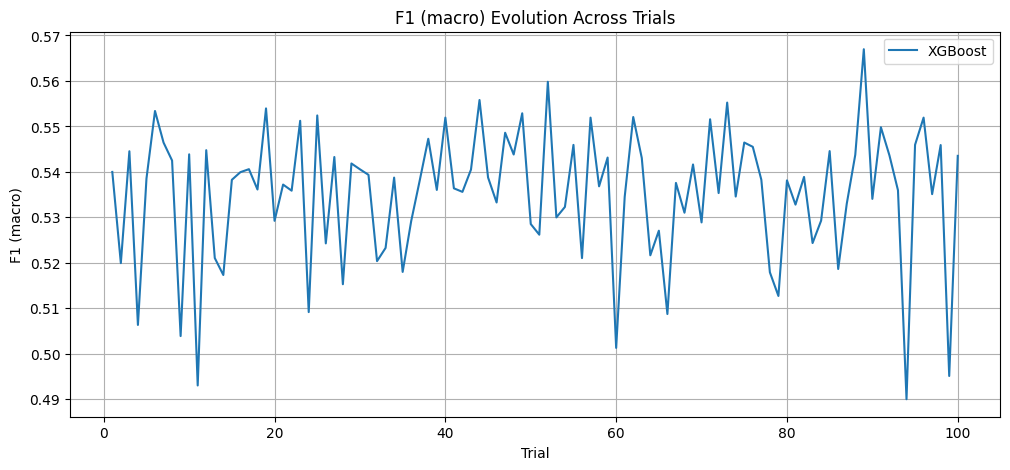

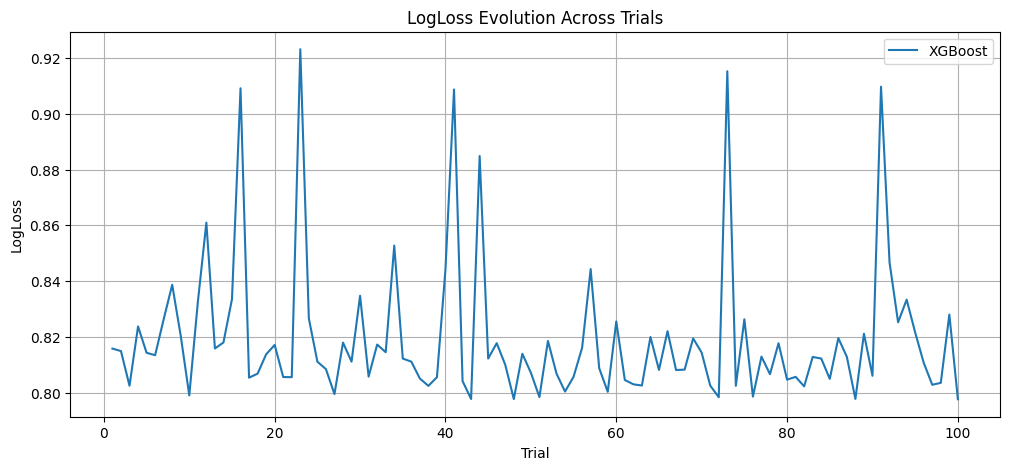

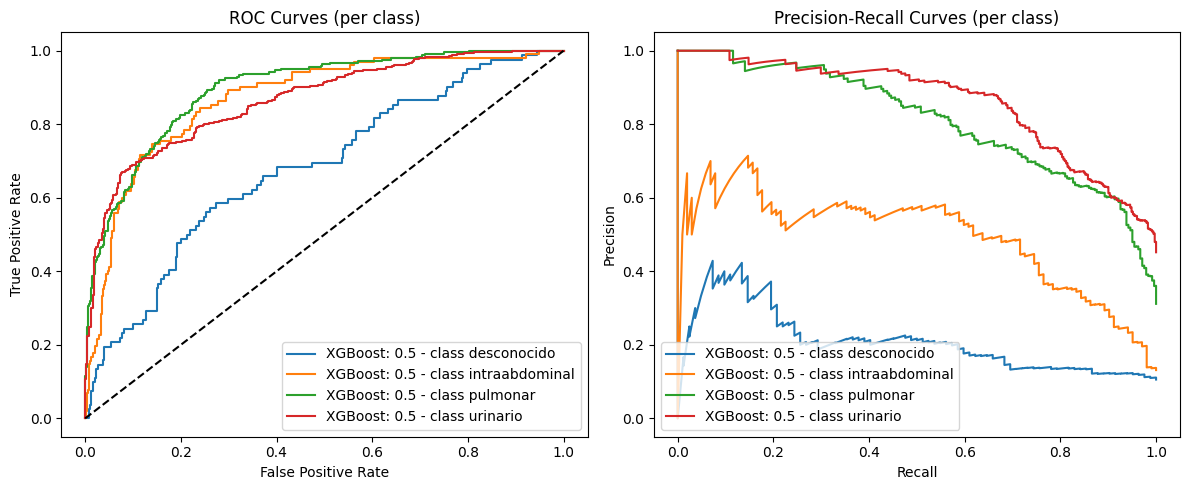

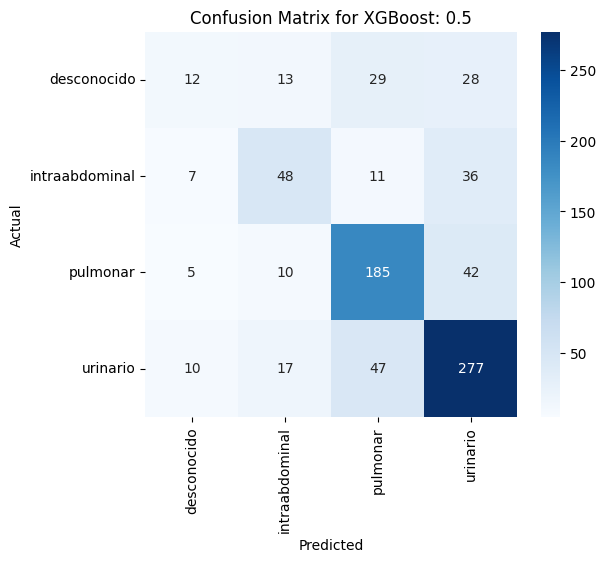

In [ ]:
import os
import pickle
import copy

def predict_with_threshold(model, X, classes, threshold=None):
    """
    Predict multiclass labels with a confidence threshold.
    If max probability < threshold → assign 'Unknown'
    """
    # Predict probabilities
    y_proba = model.predict_proba(X)

    # Get argmax and max probability
    y_pred_idx = np.argmax(y_proba, axis=1)
    y_max_prob = np.max(y_proba, axis=1)

    # Choose default threshold if not provided
    if threshold is None:
        n_classes = y_proba.shape[1]
        threshold = 1 / n_classes + 0.2  # adaptive heuristic

    # Create predicted labels
    y_pred = np.array([classes[i] if p >= threshold else "Unknown"
                       for i, p in zip(y_pred_idx, y_max_prob)])

    return y_pred, y_max_prob

def evaluate_models_multiclass(models, X_test, y_test, class_names):
    results = []
    classes = np.unique(y_test)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        y_pred = np.argmax(y_proba, axis=1)

        metrics = {
            "Model": model_name,
            "F1 (macro)": f1_score(y_test, y_pred, average="macro"),
            "Recall (macro)": recall_score(y_test, y_pred, average="macro"),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (macro)": precision_score(y_test, y_pred, average="macro"),
            "ROC AUC (macro)": roc_auc_score(y_test, y_proba, labels=model.classes_, multi_class="ovr", average="macro")
        }

        print(f"\nClassification Report for {model_name}:\n")
        print(classification_report(y_test, y_pred, target_names=[str(c) for c in class_names]))
        results.append(metrics)

    return pd.DataFrame(results)

def plot_optuna_metrics_multiclass(studies, metric_names=("F1 (macro)", "LogLoss")):
    """
    Plot the evolution of macro F1 and LogLoss across trials for each model.
    
    studies : dict
        {"ModelName": optuna.study.Study, ...}
    metric_names : tuple
        Names of the two metrics being optimized (default: F1-macro, LogLoss).
    """
    # --- Plot F1 ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_f1 = [
            trial.values[0] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_f1) + 1), trials_f1, label=f"{model_name}")
    plt.title(f"{metric_names[0]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[0])
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Plot LogLoss ---
    plt.figure(figsize=(12, 5))
    for model_name, study in studies.items():
        trials_ll = [
            trial.values[1] for trial in study.trials 
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        plt.plot(range(1, len(trials_ll) + 1), trials_ll, label=f"{model_name}")
    plt.title(f"{metric_names[1]} Evolution Across Trials")
    plt.xlabel("Trial")
    plt.ylabel(metric_names[1])
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_metrics_multiclass(models, X_test, y_test, classes, class_names):
    # ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f"{model_name} - class {class_names[i]}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curves (per class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # PR curves
    plt.subplot(1, 2, 2)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            precision, recall, _ = precision_recall_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(recall, precision, label=f"{model_name} - class {class_names[i]}")
    plt.title("Precision-Recall Curves (per class)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Confusion matrices
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix for {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()


if __name__ == "__main__":
    DATABASE_FILE = "/home/pmata/mepram_data/df_merged_full.csv"
    output_location = "/home/pmata/mepram_data/output_testing/"
    processed_df = pd.read_csv(DATABASE_FILE)
    focoss = {
        1: "pulmonar",
        2: "intraabdominal",
        3: "biliar",
        4: "urinario",
        5: "cardiovascular",
        6: "piel",
        7: "sistema nervioso central",
        8: "cateter venoso",
        9: "vías altas respiratorias",
        10: "osteoarticular",
        11: "genital",
        12: "desconocido",
    }
    processed_df["foco"] = processed_df["foco"].map(focoss)
    processed_df = processed_df[~processed_df["foco"].isin(["piel", "osteoarticular", "biliar", "genital", "sistema nervioso central", "cateter venoso", "vías altas respiratorias", "cardiovascular"])]
    #processed_df["foco"] = processed_df["foco"].map(lambda x: {"biliar": "otros", "genital": "otros", "sistema nervioso central": "otros", "cateter venoso": "otros", "vías altas respiratorias": "otros", "cardiovascular": "otros"}.get(x, x))
    output_filename = "model_comparison_foco.csv"
    cols_to_delete = ["person_id", "fecha_ingreso_urgencias", "shock_septico", "prev_ultima_fecha", "sepsis", "ultima_fecha",
        "fecha_nacimiento", "codigo_postal","fecha_ingreso_urgencias_x", "center", "dag", "mujer_gestante"]
    for col in cols_to_delete:
        try:
            processed_df = processed_df.drop(col, axis=1)
        except Exception as e:
            print(f"Could not delete column {col}: {str(e)}")
    """processed_df = copy.deepcopy(df_to_clean)
    processed_df = processed_df.fillna(0)"""

    test_df = copy.deepcopy(processed_df)
    test_df = load_clean_dataset(test_df, na_perc_limit=0.10)
    target_variable = "foco"
    encode = True
    if encode:
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        test_df[target_variable] = le.fit_transform(test_df[target_variable])
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        print(f"Encoded variables: {mapping}")
     #['taquipnea_hipotension', 'cardiovascular_estado_mental_alterado', 'estado_mental_alterado_hipotension', 'respiracion_creatinina', 'cardiovascular_taquipnea'] #selected = ['estado_mental_alterado', 'saturacion_o2', 'proteina_c_reactiva', 'respiracion', 'frec_cardiaca', 'plaquetas', 'creatinina', 'edad', 'vasopresores', 'cardiovascular', 'sepsis']
    selected = [target_variable]
    if target_variable in selected:
        X = test_df.drop(target_variable, axis=1)
    else:
        X = test_df
    y = test_df[target_variable]
    print(np.unique(y))
    scaler = MinMaxScaler()
    X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=99)
    """
    rf_study = optuna.create_study(directions=["maximize", "minimize"])
    rf_study.optimize(lambda trial: objective_random_forest(trial, X, y), n_trials=100)
    best_rf_params = rf_study.best_trials[0].params
    rf_thresh = best_rf_params.pop("threshold")
    best_rf_model = RandomForestClassifier(**best_rf_params).fit(X_train, y_train)
    #best_rf_metrics = cv_model_train(best_rf_model, X, y)

    """    
    xgb_study = optuna.create_study(directions=["maximize", "minimize"])
    xgb_study.optimize(lambda trial: objective_xgboost(trial, X, y), n_trials=100)
    best_xgb_params = xgb_study.best_trials[0].params
    xgb_thresh = 0.5#best_xgb_params.pop("threshold")
    best_xgb_model = XGBClassifier(**best_xgb_params).fit(X_train, y_train)
    #best_xgb_metrics = cv_model_train(best_xgb_model, X, y)
    
    """
    svm_study = optuna.create_study(directions=["maximize", "minimize"])
    svm_study.optimize(lambda trial: objective_svm(trial, X, y), n_trials=10)
    best_svm_params = svm_study.best_trials[0].params
    svm_thresh = 0.5#best_svm_params.pop("threshold")
    best_svm_model = SVC(**best_svm_params, probability=True).fit(X_train, y_train)
    #best_svm_metrics = cv_model_train(best_svm_model, X, y)"""

    models = {
        #f"Random Forest: {rf_thresh}": best_rf_model,
        f"XGBoost: {xgb_thresh}": best_xgb_model,
        #f"SVM: {svm_thresh}": best_svm_model
    }
    results = evaluate_models_multiclass(models, X_test, y_test, class_names=le.classes_)

    print("Model Comparison:\n", results)
    results.to_csv(os.path.join(output_location, output_filename+"_foco.csv"), index=False)
    
    """scaler_path = os.path.join(output_location, "scaler.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {scaler_path}")

    for model_name, model in models.items():
        model_path = os.path.join(output_location, f"{model_name.replace(' ', '_').lower()}_model.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model '{model_name}' saved to {model_path}")"""
    
    plot_optuna_metrics_multiclass(
        studies={
            #"Random Forest": rf_study,
            "XGBoost": xgb_study,
            #"SVM": svm_study
        },
        metric_names=("F1 (macro)", "LogLoss")
    )

    plot_metrics_multiclass(models, X_test, y_test, classes=np.unique(y), class_names=le.classes_)


Classification Report for Random Forest: 0.2846205912383386:

                precision    recall  f1-score   support

   desconocido       0.43      0.12      0.19        82
intraabdominal       0.57      0.43      0.49        74
      pulmonar       0.71      0.81      0.75       180
      urinario       0.61      0.77      0.68       200

      accuracy                           0.63       536
     macro avg       0.58      0.53      0.53       536
  weighted avg       0.61      0.63      0.60       536

Model Comparison:
                                Model  F1 (macro)  Recall (macro)  Accuracy  \
0  Random Forest: 0.2846205912383386    0.528255        0.531235  0.634328   

   Precision (macro)  ROC AUC (macro)  
0           0.580168           0.8309  


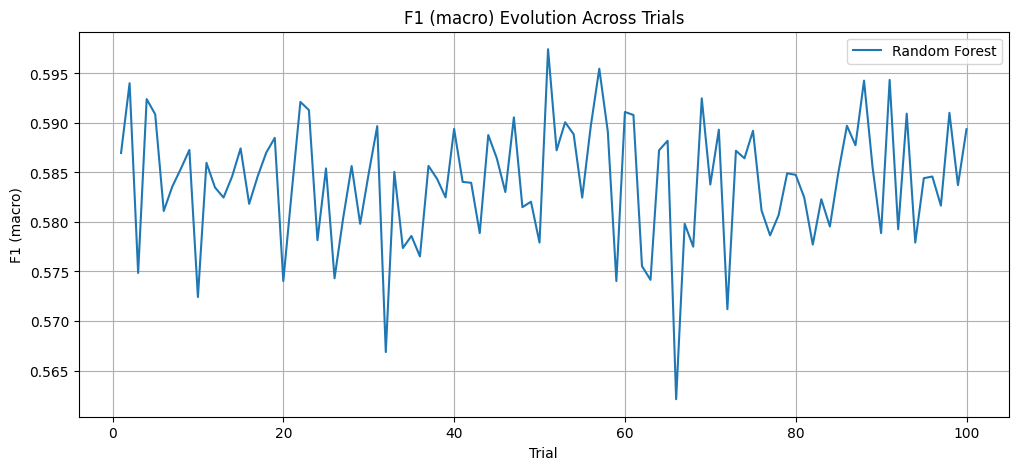

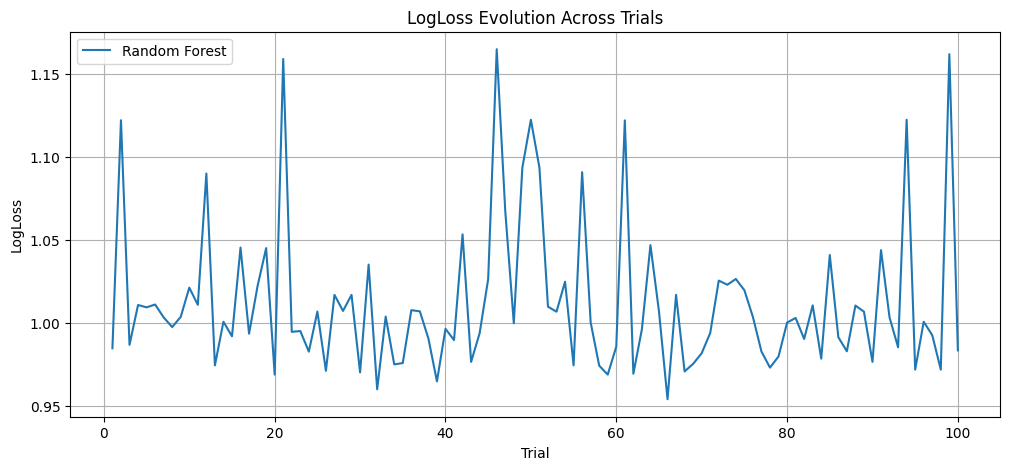

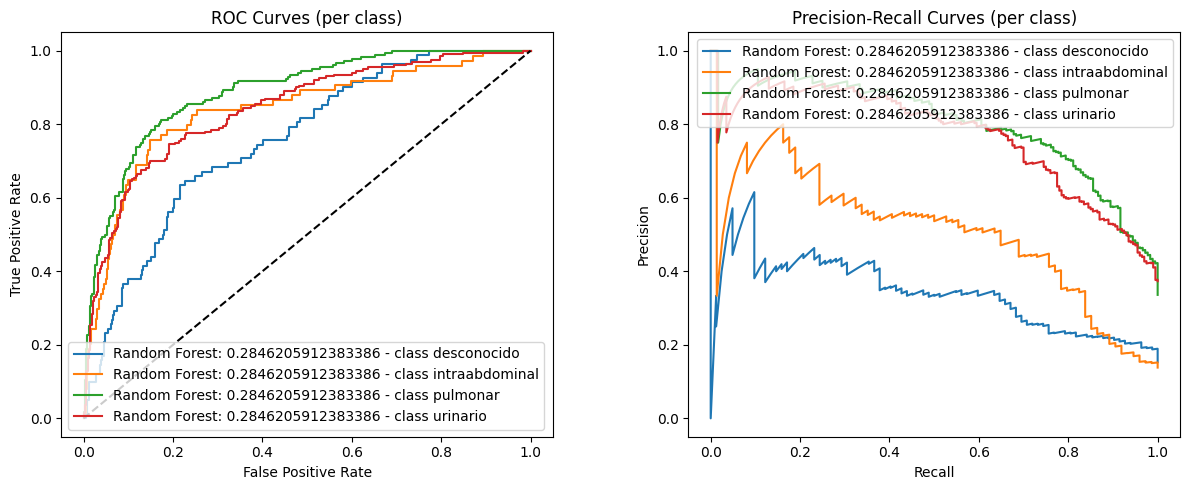

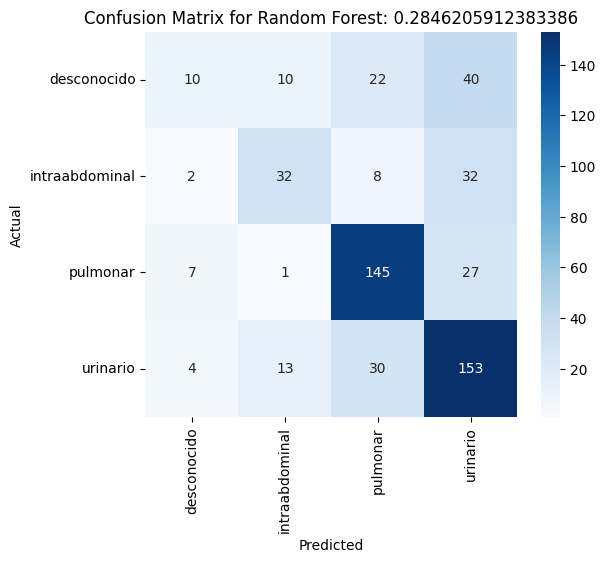

In [116]:
    rf_thresh = best_rf_params.pop("threshold")
    best_rf_model = RandomForestClassifier(**best_rf_params).fit(X_train, y_train)
    #best_rf_metrics = cv_model_train(best_rf_model, X, y)

    """    
    xgb_study = optuna.create_study(directions=["maximize", "minimize"])
    xgb_study.optimize(lambda trial: objective_xgboost(trial, X, y), n_trials=100)
    best_xgb_params = xgb_study.best_trials[0].params
    xgb_thresh = 0.5#best_xgb_params.pop("threshold")
    best_xgb_model = XGBClassifier(**best_xgb_params).fit(X_train, y_train)
    #best_xgb_metrics = cv_model_train(best_xgb_model, X, y)
    """
    """
    svm_study = optuna.create_study(directions=["maximize", "minimize"])
    svm_study.optimize(lambda trial: objective_svm(trial, X, y), n_trials=10)
    best_svm_params = svm_study.best_trials[0].params
    svm_thresh = 0.5#best_svm_params.pop("threshold")
    best_svm_model = SVC(**best_svm_params, probability=True).fit(X_train, y_train)
    #best_svm_metrics = cv_model_train(best_svm_model, X, y)"""

    models = {
        f"Random Forest: {rf_thresh}": best_rf_model,
        #f"XGBoost: {xgb_thresh}": best_xgb_model,
        #f"SVM: {svm_thresh}": best_svm_model
    }
    results = evaluate_models_multiclass(models, X_test, y_test, class_names=le.classes_)

    print("Model Comparison:\n", results)
    results.to_csv(os.path.join(output_location, output_filename+"_foco.csv"), index=False)
    
    """scaler_path = os.path.join(output_location, "scaler.pkl")
    with open(scaler_path, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"Scaler saved to {scaler_path}")

    for model_name, model in models.items():
        model_path = os.path.join(output_location, f"{model_name.replace(' ', '_').lower()}_model.pkl")
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"Model '{model_name}' saved to {model_path}")"""
    
    plot_optuna_metrics_multiclass(
        studies={
            "Random Forest": rf_study,
            #"XGBoost": xgb_study,
            #"SVM": svm_study
        },
        metric_names=("F1 (macro)", "LogLoss")
    )

    plot_metrics_multiclass(models, X_test, y_test, classes=np.unique(y), class_names=le.classes_)

In [99]:
test_df["foco"].unique()

array([3, 2, 1, 0])

In [95]:
processed_df["foco"].unique()

array(['pulmonar', 'desconocido', 'intraabdominal', 'urinario'],
      dtype=object)

In [54]:
pd.read_csv("/home/pmata/mepram_data/df_merged_dbv1.csv").shape

(2740, 200)

In [47]:
[x for x in processed_df.columns if "fecha" in x]

['ultima_fecha']

In [34]:
def plot_metrics_multiclass(models, X_test, y_test, classes, class_names):
    # ROC curves
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            fpr, tpr, _ = roc_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(fpr, tpr, label=f"{model_name} - class {class_names[i]}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curves (per class)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()

    # PR curves
    plt.subplot(1, 2, 2)
    for model_name, model in models.items():
        y_proba = model.predict_proba(X_test)
        for i, cls in enumerate(classes):
            precision, recall, _ = precision_recall_curve((y_test == cls).astype(int), y_proba[:, i])
            plt.plot(recall, precision, label=f"{model_name} - class {class_names[i]}")
    plt.title("Precision-Recall Curves (per class)")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Confusion matrices
    for model_name, model in models.items():
        y_pred = model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix for {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

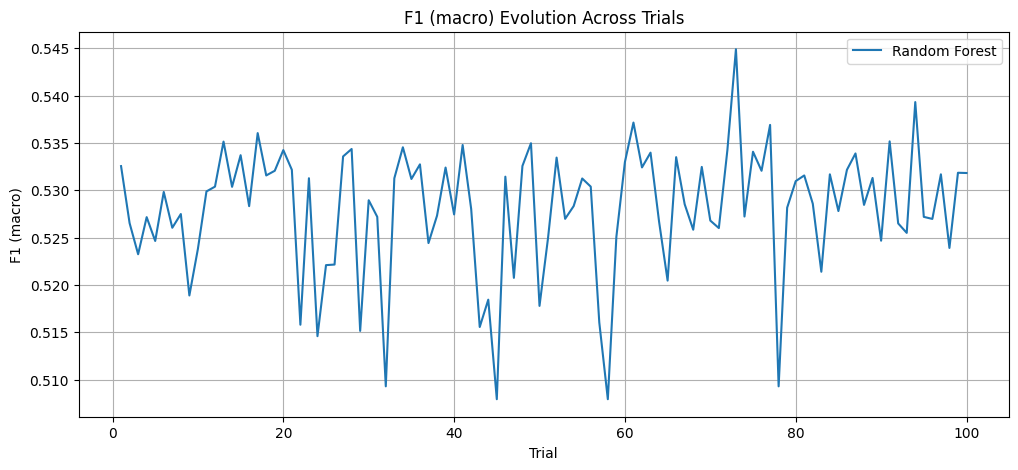

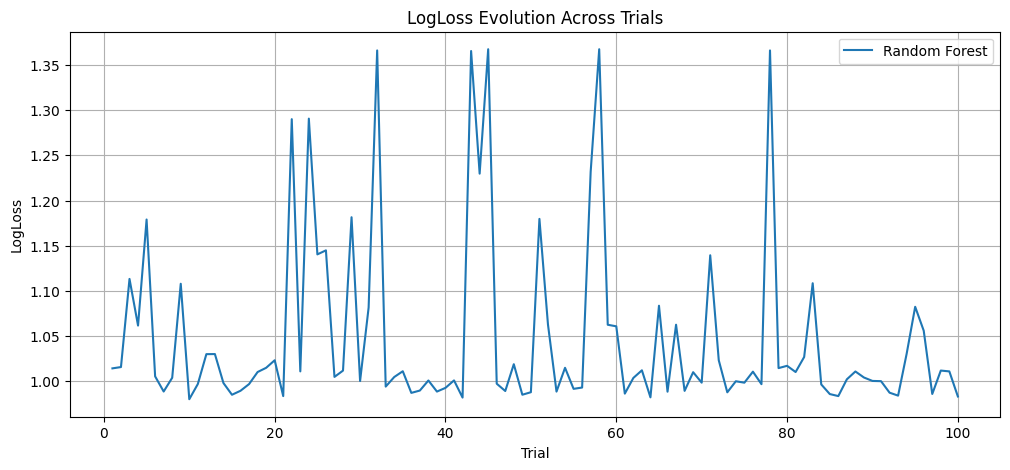

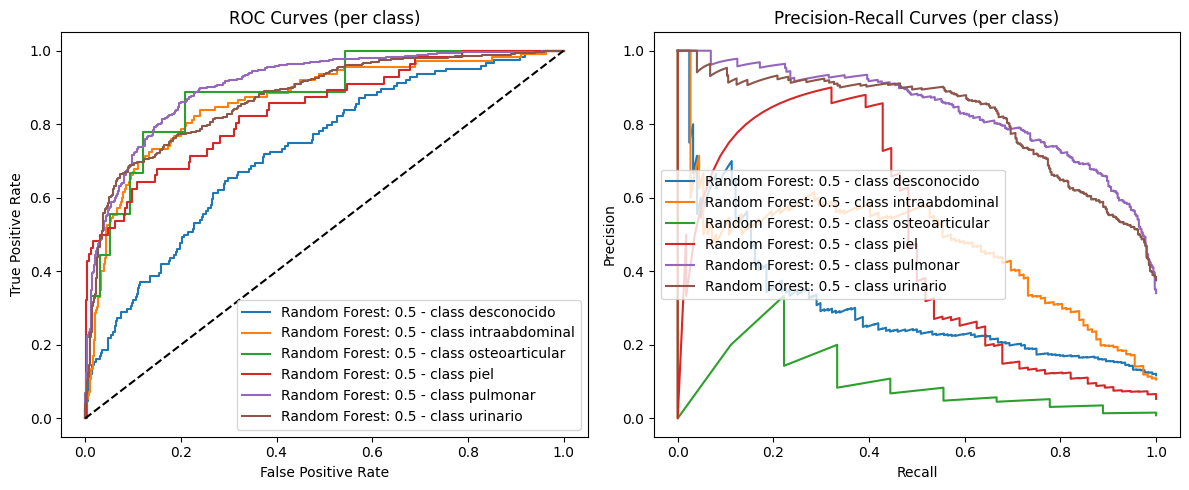

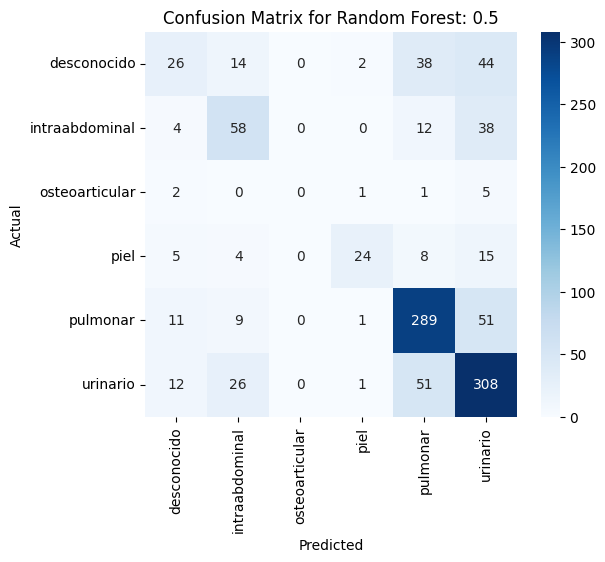

In [41]:
plot_optuna_metrics_multiclass(
    studies={
        "Random Forest": rf_study,
        #"XGBoost": xgb_study,
        #"SVM": svm_study
    },
    metric_names=("F1 (macro)", "LogLoss")
)

plot_metrics_multiclass(models, X_test, y_test, classes=np.unique(y), class_names=le.classes_)

,edad,sexo,mayor_65,paciente_residencia,inf_previa_sino,bmr_infec_previa,resultado_hemo,prev_Enterococcus,prev_Escherichia coli,prev_Klebsiella pneumoniae,...,cardiovascular,bilirrubina,plaquetas,creatinina,lactato_serico,vasopresores,proteina_c_reactiva,qsofa,estado_mental_alterado,proteina_c_reactiva_recoded
0,81,0,1,0,0,0,NEGATIVE,NaN,NaN,NaN,...,0.0,2.0,3.0,1.0,0.0,0.0,3.79,2.0,1.0,0.0
1,81,0,1,0,0,0,Enterococcus,NaN,NaN,NaN,...,0.0,0.0,3.0,1.0,1.0,0.0,1.20,0.0,0.0,0.0
2,81,0,1,0,1,0,NEGATIVE,1.0,0.0,0.0,...,0.0,0.0,4.0,1.0,0.0,0.0,5.50,1.0,0.0,1.0
3,81,0,1,0,1,0,NEGATIVE,1.0,0.0,0.0,...,0.0,1.0,4.0,1.0,1.0,0.0,10.70,2.0,0.0,1.0
4,76,1,1,0,0,0,NEGATIVE,NaN,NaN,NaN,...,0.0,0.0,4.0,0.0,1.0,0.0,4.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,43,1,0,0,0,0,Escherichia coli,NaN,NaN,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,26.55,0.0,0.0,2.0
3909,48,1,0,0,0,0,Escherichia coli,NaN,NaN,NaN,...,0.0,2.0,0.0,0.0,0.0,0.0,5.60,0.0,0.0,1.0
3910,79,0,1,0,0,0,NEGATIVE,NaN,NaN,NaN,...,0.0,0.0,1.0,2.0,1.0,0.0,21.92,1.0,0.0,2.0
3911,56,0,0,0,0,0,NEGATIVE,NaN,NaN,NaN,...,0.0,2.0,0.0,0.0,0.0,0.0,22.59,0.0,0.0,2.0


In [139]:
df_to_clean.columns

Index(['person_id', 'fecha_ingreso_urgencias', 'fecha_nacimiento', 'edad',
       'sexo', 'codigo_postal', 'mujer_gestante', 'mayor_65',
       'paciente_residencia', 'center', 'dag', 'inf_previa_sino',
       'bmr_infec_previa', 'resultado_hemo', 'fecha_ingreso_urgencias_x',
       'prev_Enterococcus', 'prev_Escherichia coli',
       'prev_Klebsiella pneumoniae', 'prev_Pseudomonas aeruginosa',
       'prev_Staphylococcus aureus', 'prev_Streptococcus pneumoniae',
       'prev__Enterobacteria', 'prev__Fungi', 'prev__Other bacteria',
       'prev__Virus', 'prev_numero_visitas', 'prev_numero_dias',
       'prev_ultima_fecha', 'prev_tiempo_ultima', 'colo_Enterococcus',
       'colo_Escherichia coli', 'colo_Klebsiella pneumoniae',
       'colo_Pseudomonas aeruginosa', 'colo_Staphylococcus aureus',
       'colo_Streptococcus pneumoniae', 'colo__Enterobacteria', 'colo__Fungi',
       'colo__Other bacteria', 'colo__Virus', 'foco', 'sepsis',
       'shock_septico', 'sofa', 'respiracion', 'snc_g

In [137]:
df_to_clean.columns

Index(['person_id', 'fecha_ingreso_urgencias', 'fecha_nacimiento', 'edad',
       'sexo', 'codigo_postal', 'mujer_gestante', 'mayor_65',
       'paciente_residencia', 'center', 'dag', 'inf_previa_sino',
       'bmr_infec_previa', 'resultado_hemo', 'fecha_ingreso_urgencias_x',
       'prev_Enterococcus', 'prev_Escherichia coli',
       'prev_Klebsiella pneumoniae', 'prev_Pseudomonas aeruginosa',
       'prev_Staphylococcus aureus', 'prev_Streptococcus pneumoniae',
       'prev__Enterobacteria', 'prev__Fungi', 'prev__Other bacteria',
       'prev__Virus', 'prev_numero_visitas', 'prev_numero_dias',
       'prev_ultima_fecha', 'prev_tiempo_ultima', 'colo_Enterococcus',
       'colo_Escherichia coli', 'colo_Klebsiella pneumoniae',
       'colo_Pseudomonas aeruginosa', 'colo_Staphylococcus aureus',
       'colo_Streptococcus pneumoniae', 'colo__Enterobacteria', 'colo__Fungi',
       'colo__Other bacteria', 'colo__Virus', 'foco', 'sepsis',
       'shock_septico', 'sofa', 'respiracion', 'snc_g

In [132]:
test_df.columns

Index(['edad', 'sexo', 'mayor_65', 'paciente_residencia', 'inf_previa_sino',
       'bmr_infec_previa', 'resultado_hemo', 'sepsis', 'respiracion',
       'cardiovascular', 'plaquetas', 'creatinina', 'lactato_serico',
       'vasopresores', 'qsofa', 'estado_mental_alterado'],
      dtype='object')

In [128]:
test_df["resultado_hemo"].value_counts()

resultado_hemo
3    2262
1     565
9     151
5     135
7     130
2     121
6      97
4      62
0      53
8       7
Name: count, dtype: int64

In [124]:
models = {
    f"Random Forest: {rf_thresh}": best_rf_model,
    f"XGBoost: {xgb_thresh}": best_xgb_model,
    #f"SVM: {svm_thresh}": best_svm_model
}
results = evaluate_models(models, X_test, y_test)
print("Model Comparison:\n", results)
results.to_csv(os.path.join(output_location, "model_comparison.csv"), index=False)

scaler_path = os.path.join(output_location, "scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {scaler_path}")
for model_name, model in models.items():
    model_path = os.path.join(output_location, f"{model_name.replace(' ', '_').lower()}_model.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model '{model_name}' saved to {model_path}")
# Plot metrics
plot_optuna_metrics(rf_study, xgb_study, svm_study)

plot_metrics(models, X_test, y_test)

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

In [ ]:
results_df = copy.deepcopy(X_test)
false_negatives_dict = {}
true_positives_dict = {}
for model_name, model in models.items():
    threshold = float(model_name.split(": ")[-1])
    model_name = model_name.split(": ")[0]
    print(f"Evaluating model: {model_name} with threshold {threshold}")
    y_pred = (model.predict_proba(X_test)[:, 1] >= threshold).astype(int).ravel()
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    results_df[model_name + '_true_label'] = y_test
    results_df[model_name + '_predicted_label'] = y_pred
    results_df[model_name + '_predicted_proba'] = y_proba
    results_df['model'] = model_name

    # Identify false negatives
    false_negatives_df = results_df[
        (results_df[model_name + '_true_label'] == 1) & 
        (results_df[model_name + '_predicted_label'] == 0)
    ]
    true_positives_df = results_df[
        (results_df[model_name + '_true_label'] == 1) & 
        (results_df[model_name + '_predicted_label'] == 1)
    ]
    false_negatives_dict[model_name] = false_negatives_df
    true_positives_dict[model_name] = true_positives_df
    print("False Negatives (", len(false_negatives_df), " instances):")
    print(false_negatives_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
available_models = false_negatives_dict.keys()
print(f"Available models: {models}")
features_to_plot = [col for col in false_negatives_df.columns if not any(model in col for model in false_negatives_dict)]
print(features_to_plot)
for feature in features_to_plot:
    # 2. Create a figure and subplots for this feature, with one subplot per model
    num_models = len(available_models)
    fig, axes = plt.subplots(ncols=num_models, figsize=(6 * num_models, 6))
    num_features = len(features_to_plot)
    for i, model in enumerate(available_models):
        true_positives_df = true_positives_dict[model]
        false_negatives_df = false_negatives_dict[model]
        sns.histplot(data=true_positives_df, x=feature, color="green", label="True Positives", kde=True, stat="density", linewidth=0, ax=axes[i])
        sns.histplot(data=false_negatives_df, x=feature, color="red", label="False Negatives", kde=True, stat="density", linewidth=0, ax=axes[i])

        axes[i].set_title(f'Model "{model}"')
        axes[i].set_xlabel(feature)
        axes[i].legend()
    fig.suptitle(f'Distribution of feature: {feature}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
from scipy.stats import ks_2samp

for model in models:
    print(f"TESTING MODEL {model} stats...")
    for col in false_negatives_dict[model].columns:
        if not any(model in col for model in models):
            feature_to_plot = col
            true_positives = true_positives_dict[model][feature_to_plot]
            false_negatives = false_negatives_dict[model][feature_to_plot]
            stat, p_value = ks_2samp(true_positives, false_negatives)
            # Combine the two dataframes for easy counting
            true_positives_df['group'] = 'True Positives'
            false_negatives_df['group'] = 'False Negatives'
            combined_df = pd.concat([true_positives_df, false_negatives_df])

            # Create the contingency table
            contingency_table = pd.crosstab(
                combined_df[feature_to_plot],
                combined_df['group'],
                normalize='index'
            )
            from scipy.stats import chi2_contingency

            # Perform the chi-squared test
            chi2, chip_value, dof, expected = chi2_contingency(contingency_table)

            print(f"\nChi-squared statistic: {chi2:.4f}")
            print(f"P-value: {p_value:.4f}")

            if chip_value < 0.05:
                print(f"Conclusion: ` {feature_to_plot} ` distribution is statistically different between True Positives and False Negatives.")
                print("Contingency Table:")
                print(contingency_table)
            if p_value < 0.05:
                print(f"{feature_to_plot} has statistical difference: K-S Statistic={stat:.4f}, P-value={p_value:.4f}")
    print(" ")


In [ ]:
[{col: X_test[col]} for col in features_to_test if not "model" in col]

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from scipy.stats import ks_2samp, chi2_contingency
from pandas.api.types import is_numeric_dtype

numerical_features = ["saturacion_o2", "tension_arterial", "frec_cardiaca", "temperatura", "edad", "indice_de_charlson"]
categorical_features = ["respiracion", "cardiovascular", "plaquetas", "creatinina", "estado_mental_alterado", "taquipnea", "hipotension", "tension_arterial_recoded"]

for model in models:
    true_positives = true_positives_dict[model]
    false_negatives = false_negatives_dict[model]
    true_positives_df['group'] = 'True Positives'
    false_negatives_df['group'] = 'False Negatives'
    combined_df = pd.concat([true_positives_df, false_negatives_df])
    features_to_test = [col for col in combined_df.columns if not any(x in col for x in ['group', 'predicted_label', 'true_label', 'predicted_proba'])]
    for feature1, feature2 in combinations(numerical_features, 2):
        print(f"\n--- Analyzing Numerical Interaction between: '{feature1}' and '{feature2}' ---")
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=combined_df, x=feature1, y=feature2, hue='group')
        plt.title(f'Scatter Plot of {feature1} vs. {feature2}')
        plt.show()
    

    
    for num_feature in numerical_features:
        for cat_feature in categorical_features:
            print(f"\n--- Analyzing Interaction: '{num_feature}' vs. '{cat_feature}' ---")
            plt.figure(figsize=(12, 6))
            sns.boxplot(data=combined_df, x=cat_feature, y=num_feature, hue='group')
            plt.title(f'Distribution of {num_feature} across {cat_feature} by Group')
            plt.show()
    

    from scipy.stats import chi2_contingency

    for feature1, feature2 in combinations(categorical_features, 2):
        print(f"\n--- Analyzing Categorical Interaction between: '{feature1}' and '{feature2}' ---")

        # Create a detailed contingency table
        contingency_table = pd.crosstab(combined_df[feature1], [combined_df[feature2], combined_df['group']])
        print(f"Contingency Table for {feature1} and {feature2}:")
        print(contingency_table)

        # A stacked bar plot is also a good visualization
        contingency_counts = pd.crosstab(combined_df[feature1], [combined_df[feature2], combined_df['group']])
        contingency_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
        plt.title(f'Stacked Bar Plot of {feature1} and {feature2} by Group')
        plt.show()

## Save tuned models

Persist best trials, trained estimators, and associated metrics for later reuse.

### Persist artefacts to disk

Serialise pipelines, study objects, and performance summaries for reproducibility and deployment.

In [ ]:
#output_dir = "path/output/"
#
#
#os.makedirs(output_dir, exist_ok=True)
#
#joblib.dump(best_rf_model, os.path.join(output_dir, "best_rf_model.pkl"))
#joblib.dump(best_xgb_model, os.path.join(output_dir, "best_xgb_model.pkl"))
#joblib.dump(best_svm_model, os.path.join(output_dir, "best_svm_model.pkl"))
#joblib.dump(scaler, os.path.join(output_dir, "scaler.pkl"))